In [3]:
import sys
import os
import glob
sys.path.append("/home/tg8455/srths/downloaded_code")
from BBSims import noise_calc
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from itertools import combinations_with_replacement as cwr
from copy import deepcopy
import astropy.units as u

from dataclasses import dataclass, field
from typing import List, Dict, Optional,Callable

I will be recreating the workflow of the previous notebook (switching bc the covariance workflow is different)

### 1. Theory

Note: This workflow is built for one iso parameter, one Fisher only. Please be careful to set the values of your desired parameters at the beginning; you should use the same array for both the theory power spectrum and the fiducial values for the Fisher (think about why: your covariance contains the cosmic variance term for a certain power spectrum, but then your -- shortcut-- dC will be constructed from an entirely different ps)

In [4]:
sys.path.append("/home/tg8455/srths/code_bases/cosmocast_makelik")
from iso_theory import compute_cls, _apply_cuts, _interp_to, make_cross_noise, knox_auto_cov, knox_cross_cov

In [5]:
ISO_TYPE_NOW = 'cdi'
CORR_TYPE_NOW = 'ucor'

LMAX_FID = 5000

theta0 = {
    "omega_b": 0.02237,
    "omega_cdm": 0.11933,
    "h": 0.6766,
    "tau_reio": 0.0561,
    "P_RR_1": 2.3e-9,
    "P_RR_2": 2.3e-9,
    "P_II_1": 1.0e-9,
    "P_II_2": 1.0e-9,
}


cmb_theo_dict = {}
if CORR_TYPE_NOW == 'ucor':
    cmb_theo_dict = compute_cls(LMAX_FID, iso_mode = ISO_TYPE_NOW, **theta0)

### 2. The Fake Likelihood

note:  I will not be importing the likelihood code from makelik, but rather writing one from scratch for the senior thesis workflow 

The new version of the likelihood is, for better or for worse, dependent on Planck Lite. The code works differently, because you will have **exactly one data vector** from which you very easily create a Knox covariance: 
- take in your req_spec and your setup so it knows what noise spectra you want (it is, in theory, still flexible to simulated Planck data, if that strikes your fancy)
- you should have your nz_dict from before (which is a data product that is UNIVERSAL; I do not need to generate it every time, I can just store it into a .yaml or sum shit, but will figure it out a bit later). From this nz_dict you build noise power spectra, which you then combine into ONE, using inverse variance ($N_{\ell} = \frac{1}{\sum_{exp}1/N^i_{\ell}}$). You can work on the ell_grid dictated by your nz_dict. You do this for all the experiments requested in your experimental setup (I will leave fake PK out for now, fly high sweet angel).
- the good thing is that you are working on a set ell_grid dictated by your *data_lite* object. now that you have your ell_noise stored for every experiment, you add the CMB theory to it, you paste the noise and the CMB theory on the same grid so now you have your C_ell + N (LAT extends beyond Planck. there you just keep the gridding that you already have ig? there's nobody stopping me lmao). For every experiment, you make a diagonal-only TTTEEE covariance (which should be stored somewhere!). You compare SAT with it below 500 and LAT above 500, and you create a new data vector, replacing SAT where it competes with Planck.

In [6]:
# importing Planck Lite:
from cobaya.likelihoods.base_classes.planck_pliklite import PlanckPlikLite

PLANCK_ROOT  = "/home/tg8455/srths/Planck/lite_2018"

dataset_files = glob.glob(os.path.join(PLANCK_ROOT, "**", "*plik*lite*.dataset"), recursive=True)
#print("\n".join(dataset_files[:10]))

dataset = [f for f in dataset_files if "lite" in os.path.basename(f)][0]

lite = PlanckPlikLite({"dataset_file": dataset})

cov_lite = lite.cov          # nuisance-marginalized covariance (after any cuts)
data_lite = lite.X_data      # corresponding data vector entries
#print(cov_lite.shape, data_lite.shape)

In [7]:
# below, I'll input tbhe Planck constants:
# note!! for the choice of delta_ells based on ell see PK18V

nbins_pk = {'TT':215,'TE':199,'EE':199}
cuts_pk = {'TT': [30,2508],'TE': [30,1996],'EE': [30,1996] }
ell_mid = (lite.blmin+lite.blmax)/2
dell = lite.blmax[lite.blmax<=2508] - lite.blmin[lite.blmin<=2476]  + 1
ell_pk ={ 'TT': ell_mid[ell_mid <= 2508], 'TE': ell_mid[ell_mid <= 1996], 'EE': ell_mid[ell_mid <= 1996]}

lite_data = {
    'TT': {
        'c_ell': data_lite[:215],
        'cov': np.diag(cov_lite)[:215],
        'ell': ell_pk['TT'],
        'dell': dell,
    },
    'TE': {
        'c_ell': data_lite[215:414],
        'cov': np.diag(cov_lite)[215:414],
        'ell': ell_pk['TE'],
        'dell': dell[:199],
    },
    'EE': {
        'c_ell': data_lite[414:],
        'cov': np.diag(cov_lite)[414:],
        'ell': ell_pk['EE'],
        'dell': dell[:199]
    },
}

now, to make the noise dict again:

In [8]:
SO_FREQ  = [27.0,39.0,93.0, 145.0,225.0,280.0]
SO_CMB_FREQ = [93.0,145.0]
PK_FREQ = [100.0,143.0,217.0,353.0]
PK_CMB_FREQ = [100.0,143.0]

frequencies = {
    "LAT": ["027", "039", "093", "145", "225", "280"],
    "SAT": ["027", "039", "093", "145", "225", "280"],
    "PK": ["100", "143", "217", "353"]
}
SAT_pairs_cmb = ['SAT_093xSAT_093',
                'SAT_145xSAT_145',
                 'SAT_093xSAT_145',
                ]
LAT_pairs_cmb = [s.translate(str.maketrans('S','L')) for s in SAT_pairs_cmb]
                 
LAT_pairs_all = ["LAT_027xLAT_027",
               "LAT_039xLAT_039",
               "LAT_093xLAT_093",
               "LAT_145xLAT_145",
               "LAT_225xLAT_225",
               "LAT_280xLAT_280",
               "LAT_027xLAT_039",
               "LAT_093xLAT_145",
               "LAT_225xLAT_280"]

SAT_pairs_all = [s.translate(str.maketrans('L','S')) for s in LAT_pairs_all]

PK_pairs_cmb = ['PK_100xPK_100', 
                'PK_143xPK_143',
                'PK_100xPK_143']
PK_pairs_all = ["PK_{}xPK_{}".format(*cross) for cross in cwr(frequencies["PK"], 2)]

In [9]:
experiment = {}
experiment["label"] = 'SAT'
experiment['c_ell_params'] = {}
experiment['c_ell_params']['cuts'] = [30,400]

'''
experiment["label"] = 'LAT'
experiment['c_ell_params'] = {}
experiment['c_ell_params']['cuts'] = [400,3000]'''

'\nexperiment["label"] = \'LAT\'\nexperiment[\'c_ell_params\'] = {}\nexperiment[\'c_ell_params\'][\'cuts\'] = [400,3000]'

In [10]:
# generating noise:
def add_case(experiment1,dict_init = None,yrs = 1,sens_mode = 1, f_mode = 0, lmax = 10_000, fsky = 0.1, dell = 10, cuts = [30,300]):
    '''make f_mode negative if there is no such thing in the experiment for LAT
        the function needs to be called any time you want to add a case'''
    new_dict = deepcopy(dict_init)
    if not dict_init:
        new_dict = {}
    if experiment1 == 'SAT':
        key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(experiment1,yrs ,sens_mode,f_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'f_mode' : f_mode,
        'fsky' : fsky,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
                        }
    elif experiment1 == 'LAT' or experiment1 == 'LAT_pol':
        key = "{}_y{:.0f}_sm{:.0f}".format(experiment1, yrs,sens_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'fsky' : fsky,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
            }
    return new_dict

In [11]:
cases = {'SAT':{}, 'LAT':{},'LAT_pol':{}}
for i in np.arange(1,6):
    cases['SAT'] = add_case('SAT',yrs = float(i), dict_init = cases['SAT'], lmax = 400, dell = 10, cuts = [30,400])
cases['SAT'] = add_case('SAT',yrs = float(10), lmax = 400, dell = 10,dict_init =  cases['SAT'],cuts = [30,400])

In [12]:
LAT_LMAX = 3000
LAT_LMIN = 400

for i in np.arange(1,6):
    cases['LAT'] = add_case('LAT',yrs = float(i), dict_init = cases['LAT'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])
    cases['LAT_pol'] = add_case('LAT_pol',yrs = float(i), dict_init = cases['LAT_pol'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])
cases['LAT'] = add_case('LAT',yrs = float(10), dict_init = cases['LAT'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])
cases['LAT_pol'] = add_case('LAT_pol',yrs = float(10), dict_init = cases['LAT_pol'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])

In [13]:
def make_nz_dict_from_array(nz_array,freq_dict,experiment):
    '''
    f_000 stores the N_ell for f_000xf_000, in units of ; constructed with 'frequencies' dict in mind
    '''
    nz_dict = {}
    for i,name in enumerate(freq_dict[experiment]):
        if len(name) ==2:
            nz_dict['f0{}'.format(name)] = nz_array[i]
        else:
            nz_dict['f{}'.format(name)] = nz_array[i]
    return nz_dict

In [14]:
full_noise_dict = deepcopy(cases)
for name in cases['SAT'].keys():
    case = deepcopy(cases['SAT'][name])
    ellplot_SA, polnz_SA, whnz_SA = noise_calc.Simons_Observatory_V3_SA_noise(
            case["sens_mode"], case["f_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'], beam_stuff = True)
    nz_dict = make_nz_dict_from_array(polnz_SA,frequencies,'SAT')
    full_noise_dict['SAT'][name]['nz_dict'] = nz_dict
    full_noise_dict['SAT'][name]['ell_nz'] = ellplot_SA

for name in cases['LAT'].keys():
    case = deepcopy(cases['LAT'][name])
    ellplot_LA, tempnz_LA, polnz_LA, whnz_LA = noise_calc.Simons_Observatory_V3_LA_noise(
            case["sens_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'])
    nz_dict = make_nz_dict_from_array(tempnz_LA,frequencies,'LAT')
    full_noise_dict['LAT'][name]['nz_dict'] = nz_dict
    full_noise_dict['LAT'][name]['ell_nz'] = ellplot_LA

for name in cases['LAT_pol'].keys():
    case = deepcopy(cases['LAT_pol'][name])
    ellplot_LA, tempnz_LA, polnz_LA, whnz_LA = noise_calc.Simons_Observatory_V3_LA_noise(
            case["sens_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'])
    nz_dict = make_nz_dict_from_array(polnz_LA,frequencies,'LAT')
    full_noise_dict['LAT_pol'][name]['nz_dict'] = nz_dict
    full_noise_dict['LAT_pol'][name]['ell_nz'] = ellplot_LA

### adding the Planck noise (#prayforme)

In [15]:
lmin_tt = 30
lmax_tt = 2000
lmin_ee = 30
lmax_ee = 2000
dell_tt = 10
dell_ee = 10

ell_pk_tt = np.arange(lmin_tt,lmax_tt, dell_tt)
ell_pk_ee = np.arange(lmin_ee,lmax_ee, dell_ee)

sigma = {"PK_100xPK_100":0.,
        "PK_143xPK_143":0.,
        "PK_217xPK_217":0.,
        "PK_353xPK_353":0.,
        }
sigma_pol = deepcopy(sigma)


# converted temperature noise level from Table 4 of 1807.06205 to micro-Kelvin*arcmin
sigma["PK_100xPK_100"] = 77.4
sigma["PK_143xPK_143"] = 33.0
sigma["PK_217xPK_217"] = 46.80
sigma["PK_353xPK_353"] = 153.6

# converted polarization noise level from Table 4 of 1807.06205 to micro-Kelvin*arcmin
sigma_pol["PK_100xPK_100"] = 117.6
sigma_pol["PK_143xPK_143"] = 70.2
sigma_pol["PK_217xPK_217"] = 105.0
sigma_pol["PK_353xPK_353"] = 438.6

ttnz_PK = np.zeros((4,len(ell_pk_tt)))
eenz_PK = np.zeros((4,len(ell_pk_ee)))

# Planck beam FWHMs in arcminutes from Table 4 of Planck 2018 I (1807.06205)
beam_PK_100 = 9.66
beam_PK_143 = 7.22
beam_PK_217 = 4.90
beam_PK_353 = 4.92

PK_beams = np.array([beam_PK_100, beam_PK_143, beam_PK_217, beam_PK_353])
PK_beams_rad = PK_beams / np.sqrt(8. * np.log(2)) / 60. * np.pi / 180.
# beam sigma in radians, same convention as SO

for i, f_pair in enumerate(sigma.keys()):
    sigma_rad = np.deg2rad(sigma[f_pair] / 60)
    ttnz_PK[i] = sigma_rad**2 * 4 * np.pi * np.exp(ell_pk_tt * (ell_pk_tt + 1) * PK_beams_rad[i]**2)

    sigma_pol_rad = np.deg2rad(sigma_pol[f_pair] / 60)
    eenz_PK[i] = sigma_pol_rad**2 * 4 * np.pi * np.exp(ell_pk_ee * (ell_pk_ee + 1) * PK_beams_rad[i]**2)



full_noise_dict['PK'] = { 'lmax':lmax_tt,
                          'dell':dell_tt,
                          'fsky':1.0,
                          'cuts':[lmin_tt,lmax_tt],
                          'nz_dict':  make_nz_dict_from_array( ttnz_PK,frequencies,'PK'),
                          'ell_nz':ell_pk_tt,
                        }
full_noise_dict['PK_pol'] = { 'lmax':lmax_ee,
                              'dell':dell_ee,
                              'fsky':1.0,
                              'cuts':[lmin_ee,lmax_ee],
                              'nz_dict':  make_nz_dict_from_array( eenz_PK,frequencies,'PK'),
                              'ell_nz' : ell_pk_ee,
                                }
full_noise_dict['PK_cross'] = { 'lmax':lmax_ee,
                                'dell':dell_ee,
                                'fsky':1.0,
                                'cuts':[lmin_ee,lmax_ee],
                                'nz_dict': None,
                                'ell_nz' : ell_pk_ee,
                                }

In [16]:
def _make_pref(ell_plot):
    return ell_plot * (ell_plot+1)/(2*np.pi)

In [17]:
'''
# N_ell plots for TT
dict_temp = full_noise_dict['PK']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'PK, {text}'.format(text = key))
    plt.ylabel(r'$\mu K^2$ * $A_{sky}$')

dict_temp = full_noise_dict['LAT']['LAT_y5_sm1']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'LAT 5 yr, {text}'.format(text = key))
    plt.title('TT noise')
    plt.ylabel(r'$\mu K^2$ * $A_{sky}$')

plt.loglog()
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.show()

# N_ell plots for EE

dict_temp = full_noise_dict['PK_pol']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'PK, {text}'.format(text = key))

dict_temp = full_noise_dict['SAT']['SAT_y5_sm1fm0']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'SAT 5 yr, {text}'.format(text = key))

    
dict_temp = full_noise_dict['LAT_pol']['LAT_pol_y5_sm1']
for key in dict_temp['nz_dict'].keys():
    ell_plot = dict_temp['ell_nz']
    spect = dict_temp['nz_dict'][key]
    plt.plot(ell_plot,spect, label = 'LAT 5 yr, {text}'.format(text = key))
    plt.title('EE noise')
    plt.ylabel(r'$\mu K^2$ * $A_{sky}$')

plt.loglog()
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
'''

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_469547/4115532049.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(r'$\mu K^2$ * $A_{sky}$')


"\n# N_ell plots for TT\ndict_temp = full_noise_dict['PK']\nfor key in dict_temp['nz_dict'].keys():\n    ell_plot = dict_temp['ell_nz']\n    spect = dict_temp['nz_dict'][key]\n    plt.plot(ell_plot,spect, label = 'PK, {text}'.format(text = key))\n    plt.ylabel(r'$\\mu K^2$ * $A_{sky}$')\n\ndict_temp = full_noise_dict['LAT']['LAT_y5_sm1']\nfor key in dict_temp['nz_dict'].keys():\n    ell_plot = dict_temp['ell_nz']\n    spect = dict_temp['nz_dict'][key]\n    plt.plot(ell_plot,spect, label = 'LAT 5 yr, {text}'.format(text = key))\n    plt.title('TT noise')\n    plt.ylabel(r'$\\mu K^2$ * $A_{sky}$')\n\nplt.loglog()\nplt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)\nplt.show()\n\n# N_ell plots for EE\n\ndict_temp = full_noise_dict['PK_pol']\nfor key in dict_temp['nz_dict'].keys():\n    ell_plot = dict_temp['ell_nz']\n    spect = dict_temp['nz_dict'][key]\n    plt.plot(ell_plot,spect, label = 'PK, {text}'.format(text = key))\n\ndict_temp = full_noise_dict['SAT']['SAT_

/tmp/ipykernel_469547/2334919624.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


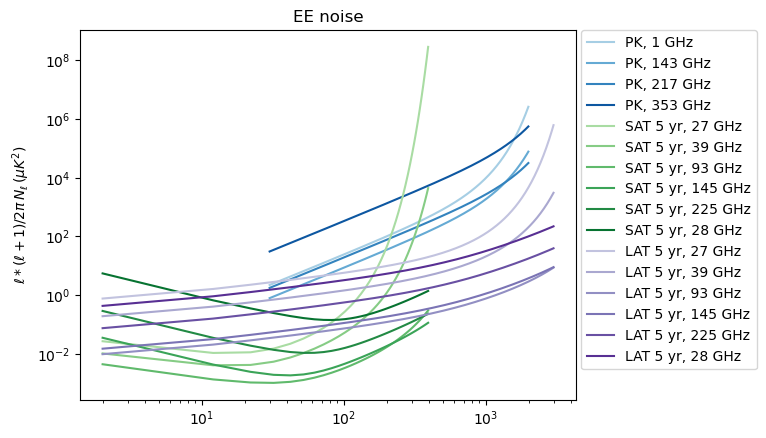

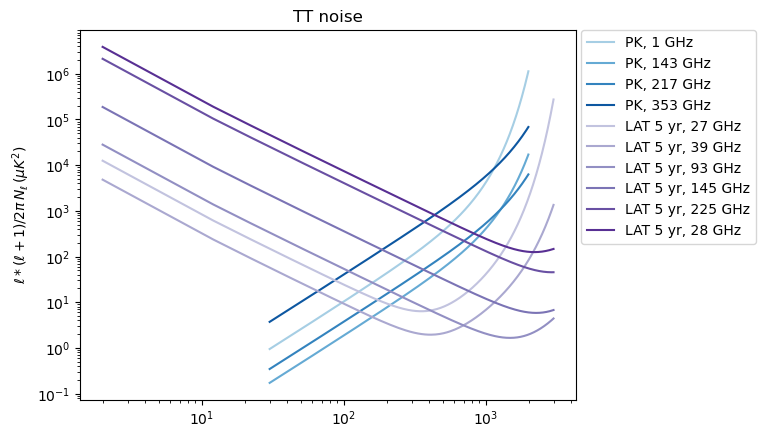

In [76]:
import matplotlib.cm as cm

def get_colors(n, cmap_name):
    cmap = cm.get_cmap(cmap_name)
    return [cmap(x) for x in np.linspace(0.35, 0.85, max(n, 1))]


color_families = {
    'PK':      'Blues',
    'SAT':     'Greens',
    'LAT_pol': 'Purples',
}

plot_groups = {
    'PK':      ('PK_pol',    None,                    'PK'),
    'SAT':     ('SAT',       'SAT_y5_sm1fm0',         'SAT 5 yr'),
    'LAT_pol': ('LAT_pol',   'LAT_pol_y5_sm1',        'LAT 5 yr'),
}

for family, (top_key, sub_key, label_prefix) in plot_groups.items():
    dict_temp = full_noise_dict[top_key] if sub_key is None else full_noise_dict[top_key][sub_key]
    nz_dict   = dict_temp['nz_dict']
    ell_plot  = dict_temp['ell_nz']
    colors    = get_colors(len(nz_dict), color_families[family])




    for (key, spect), color in zip(nz_dict.items(), colors):
        key_fig = key.replace("f", "")
        if "0" in key_fig:
            key_fig = key_fig.replace("0", "")
        key_fig+= ' GHz'
        
        pref = ell_plot*(ell_plot+1)/2/np.pi
        plt.plot(ell_plot, pref * spect, color=color, label=f'{label_prefix}, {key_fig}')

plt.title('EE noise')
plt.ylabel(r'$\ell*(\ell+1)/2\pi \, N_\ell \, (\mu K^2)$')
plt.loglog()
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.savefig('images/ee_noise.png', dpi=300, bbox_inches='tight')
plt.show()

color_families = {
    'PK':  'Blues',
    'LAT': 'Purples',
}

plot_groups = {
    'PK':  ('PK',  None,          'PK'),
    'LAT': ('LAT', 'LAT_y5_sm1',  'LAT 5 yr'),
}

for family, (top_key, sub_key, label_prefix) in plot_groups.items():
    dict_temp = full_noise_dict[top_key] if sub_key is None else full_noise_dict[top_key][sub_key]
    nz_dict   = dict_temp['nz_dict']
    ell_plot  = dict_temp['ell_nz']
    colors    = get_colors(len(nz_dict), color_families[family])


    for (key, spect), color in zip(nz_dict.items(), colors):
        key_fig = key.replace("f", "")
        if "0" in key_fig:
            key_fig = key_fig.replace("0", "")
        key_fig+= ' GHz'

        pref = ell_plot*(ell_plot+1)/2/np.pi
        plt.plot(ell_plot, pref * spect, color=color, label=f'{label_prefix}, {key_fig}')

plt.title('TT noise')
plt.ylabel(r'$\ell*(\ell+1)/2\pi \, N_\ell \, (\mu K^2)$')
plt.loglog()
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.savefig('images/tt_noise.png', dpi=300, bbox_inches='tight')
plt.show()

ok, so the way I think this is going to go is that I will save one big dict with ALL the dichroic combinations, and for each point in your 'data' dict, you save the noise spectrum and the theory spectrum that you are using (projected on the same ell_range), and from this one you take and build your singular power spectra

so actually, there is no harm in reusing the full_lik_data mentality, since that is what you will be using to create the combined noise as well. I just think I want to modify the algorithm so that it stores the C_ell and the Noise separately.

In [19]:
def build_full_lik_data(req_spec, setup, full_noise_dict, cmb_theo_dict):
    '''req_spec is a dict that tells you first what experiments you will want in your likelihood,
    and for each what spectra and what frequencies.
    in the way this is currently set up (which can be subject to change),
    your full_noise_dict is what sets the tone for the cuts, the binning, etc.'''

    from iso_theory import _apply_cuts, _interp_to, make_cross_noise
    full_lik_data = {'metadata':{}, 
                    'data':{},
                    }
    #input the power spectra that you desire:
    for exp_key in req_spec:
        check_cross = False
        if exp_key in setup.keys():
            setup_exp = setup[exp_key]
        
        if exp_key == 'SAT':
            case_key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'
        elif exp_key == 'LAT' :
            case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'])
            c_ell_theo = cmb_theo_dict['TT']
            cell_type = 'TT'

        elif exp_key == 'LAT_pol' :
            case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'])
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'

        elif exp_key == 'LAT_cross':
            check_cross = True
            case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'])
            c_ell_theo = cmb_theo_dict['TE']
            cell_type = 'TE'
          
        elif exp_key == 'PK' :
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['TT']
            cell_type = 'TT'

        
        elif exp_key == 'PK_pol' :
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'

            
        elif exp_key == 'PK_cross':
            check_cross = True
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['TE']
            cell_type = 'TE'

        pairs_current = req_spec[exp_key]
        if not check_cross:
            #for PK et.al:
            if case_key  in full_noise_dict.keys():
                nz_dict = deepcopy(full_noise_dict[case_key]['nz_dict'])
                meta = deepcopy(full_noise_dict[case_key])
            # for SO
            elif case_key  in full_noise_dict[exp_key].keys():
                nz_dict = deepcopy(full_noise_dict[exp_key][case_key]['nz_dict'])
                meta = deepcopy(full_noise_dict[exp_key][case_key])
            else:
                raise KeyError("nu exista in dict")
        ### note: this is a way of handling TE noise (i.e. we are considering no TE noise, which is not accurate at all but what can I do)
        else:
            nz_dict = {}

        full_lik_data['metadata'][exp_key] = deepcopy(meta)
        full_lik_data['metadata'][exp_key].pop('nz_dict')
        full_lik_data['metadata'][exp_key].pop('ell_nz')
        full_lik_data['metadata'][exp_key]['cell_type'] = cell_type
        full_lik_data['data'][exp_key] = {}
        for spec_key in pairs_current:
            left, right = spec_key.split('x')
            f1 = left.split('_')[-1]
            f2 = right.split('_')[-1]
            
            ell_new = meta['ell_nz']
            ell_old = cmb_theo_dict['ell']
            cuts = meta['cuts']
            ell_old_cut, cell_cmb_cut = _apply_cuts(c_ell_theo, cmb_theo_dict['ell'], cuts)
            cell_cmb_cut = _interp_to(ell_new, ell_old_cut,cell_cmb_cut)
            ell_new_cut, cell_cmb_cut = _apply_cuts(cell_cmb_cut, ell_new, cuts)
            if not check_cross:
                if f1 == f2:
                    nz_arr = nz_dict['f{}'.format(f1)]
                    _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
                else:
                    nz_arr = make_cross_noise(nz_dict['f{}'.format(f1)],nz_dict['f{}'.format(f2)])
                    _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
            else:
                nz_arr_cut = cell_cmb_cut*0
            full_lik_data['data'][exp_key][spec_key] = {'c_ell' : cell_cmb_cut, 'n_ell': nz_arr_cut,'ell': ell_new_cut}

    return full_lik_data


In [20]:
def print_keys(data, indent=0):
    for key, value in data.items():
        # Print the key with indentation for visual hierarchy
        print("  " * indent + str(key))
        
        # If the value is a nested dictionary, recurse
        if isinstance(value, dict):
            print_keys(value, indent + 1)

#print_keys(lite_data)

In [21]:
exp_types = {'TT': ['PK','LAT'],
            'TE':['PK_cross','LAT_cross'],
             'EE':['PK_pol','LAT_pol','SAT'],
            }

def extract_ell_scheme(data):
    return {
        pol: {
            'ell':  data[pol]['ell'],
            'dell': data[pol]['dell'],
        }
        for pol in ('TT', 'TE', 'EE')
    }

ell_scheme = extract_ell_scheme(lite_data)

In [243]:
def add_lite_to_out(out,lite_data, fsky_lite = 0.6):
    lite_corresp = {'PK_lite':'TT',
                    'PK_lite_pol':'EE',
                    'PK_lite_cross':'TE'
                   }
    for key in lite_corresp.keys():
        out['metadata'][key] = {
            'fsky' : fsky_lite
        }

    #we need to determine noise independently because C_ell^TE requires the other two fml
    # making Gaussian approximation here ig for the diagonal but what can you do??
    
    #TT
    exp = 'TT'
    c_ell_tt = lite_data[exp]['c_ell']
    cov = lite_data[exp]['cov']
    ell = lite_data[exp]['ell']
    dell = lite_data[exp]['dell']
    covpref = 2/(2*ell+1)/fsky_lite/dell
    n_ell_tt = np.sqrt(cov/covpref) - c_ell_tt
    
    
    #EE
    
    exp = 'EE'
    c_ell_ee = lite_data[exp]['c_ell']
    cov = lite_data[exp]['cov']
    ell = lite_data[exp]['ell']
    dell = lite_data[exp]['dell']
    covpref = 2/(2*ell+1)/fsky_lite/dell
    n_ell_ee = np.sqrt(cov/covpref) - c_ell_ee
    
    #TE
    
    exp = 'TE'
    c_ell_te = lite_data[exp]['c_ell']
    cov = lite_data[exp]['cov']
    ell = lite_data[exp]['ell']
    dell = lite_data[exp]['dell']
    covpref = 1/(2*ell+1)/fsky_lite/dell
    
    cte_signed = cov/covpref - (c_ell_tt[:199] + n_ell_tt[:199]) * (c_ell_ee + n_ell_ee)
    cte_new    = np.sign(cte_signed) * np.sqrt(np.abs(cte_signed))

    n_ell_te = cte_new - c_ell_te

    noise_corresp = {'PK_lite': n_ell_tt,
                    'PK_lite_pol': n_ell_ee,
                     #putting no noise in for now; this is ok
                    'PK_lite_cross':n_ell_ee*0
                   }
    
    for key in lite_corresp.keys():
        out['data'][key] = {
                    'c_ell': lite_data[lite_corresp[key]]['c_ell'],
                    'n_ell': noise_corresp[key],
                    'cov':   lite_data[lite_corresp[key]]['cov'],
                    'ell':lite_data[lite_corresp[key]]['ell'],
                    'dell': lite_data[lite_corresp[key]]['dell'],
                }
    return out

    
def _build_ell_grid(ell_data, ell_scheme, ell_scheme_high_ref=None):
    lmin_data  = ell_data.min()
    lmax_data  = ell_data.max()
    lmin_schem = ell_scheme.min()
    lmax_schem = ell_scheme.max()

    dell_low  = ell_scheme[1] - ell_scheme[0]

    if lmin_data < lmin_schem:
        low_ext = np.arange(lmin_schem - dell_low, lmin_data - 1, -dell_low)[::-1]
    else:
        low_ext = np.array([])

    mid = ell_scheme[(ell_scheme >= lmin_data) & (ell_scheme <= lmax_data)]

    if lmax_data > lmax_schem:
        if ell_scheme_high_ref is not None:
            # follow the TT scheme where it covers, then use its last dell beyond
            dell_high   = ell_scheme_high_ref[-1] - ell_scheme_high_ref[-2]
            lmax_ref    = ell_scheme_high_ref.max()
            # bins from TT scheme that are beyond our scheme but within TT's range
            ref_ext     = ell_scheme_high_ref[(ell_scheme_high_ref > lmax_schem) &
                                              (ell_scheme_high_ref <= lmax_data)]
            # bins beyond TT's range, using TT's last dell
            if lmax_data > lmax_ref:
                far_ext = np.arange(lmax_ref + dell_high, lmax_data + 1, dell_high)
            else:
                far_ext = np.array([])
            high_ext = np.concatenate([ref_ext, far_ext])
        else:
            dell_high = ell_scheme[-1] - ell_scheme[-2]
            high_ext  = np.arange(lmax_schem + dell_high, lmax_data + 1, dell_high)
    else:
        high_ext = np.array([])

    return np.concatenate([low_ext, mid, high_ext])


def make_unified_noise(full_lik_data, ell_scheme, add_lite=False, lite_data=None):
    '''
    this function takes in a dict like full_lik_data and a universal ell scheme (bin centers + bin sizes) for TT, TE, EE
    returns dict with the same metadata, and same data keys, but you will have ONE c_ell for every experiment
    (it is the same for the same exp_key) and ONE noise spectrum (determined from inverse variance weighting)
    if the spectrum you project has data outside the ell_ranges dictated by cuts, take the first/last bin size
    and extend that to bin your spectrum all the way, but the ell_min and ell_max are dictated by the data
    '''
    # mapping from TE instrument to its TT and EE counterparts
    _cross_to_auto = {
        'PK_cross':  ('PK',  'PK_pol'),
        'LAT_cross': ('LAT', 'LAT_pol'),
    }
    exp_types = {
        'TT': ['PK', 'LAT'],
        'EE': ['PK_pol', 'LAT_pol', 'SAT'],
        'TE': ['PK_cross', 'LAT_cross'],   # TE last — needs TT and EE already done
    }
    out = {
        'metadata': full_lik_data['metadata'],
        'data': {}
    }

    # TE and EE use TT's scheme as the high-end reference so bin centers align
    ell_tt_scheme = ell_scheme['TT']['ell']

    for pol, instruments in exp_types.items():
        ell_schem  = ell_scheme[pol]['ell']
        dell_schem = ell_scheme[pol]['dell']

        for inst in instruments:

            # skip instruments not present in the data
            if inst not in full_lik_data['data']:
                continue

            cross_spectra = full_lik_data['data'][inst]

            # all cross-spectra share the same ell grid — take from first
            first    = next(iter(cross_spectra.values()))
            ell_data = first['ell']

            # build the output ell grid respecting data range + scheme binning
            # TE and EE follow TT's high-end binning pattern to ensure alignment
            if pol in ('TE', 'EE'):
                ell_out = _build_ell_grid(ell_data, ell_schem,
                                          ell_scheme_high_ref=ell_tt_scheme)
            else:
                ell_out = _build_ell_grid(ell_data, ell_schem)

            # bin widths on the output grid (constant extrapolation at boundaries)
            dell_out = _interp_to(ell_out, ell_schem, dell_schem)

            # fsky from metadata
            fsky = full_lik_data['metadata'][inst]['fsky']

            # c_ell: same for all cross-spectra within the instrument
            c_ell_out = _interp_to(ell_out, ell_data, first['c_ell'])

            # n_ell: inverse-variance weighting to one unified noise spectrum
            inv_noise_sum = np.zeros(len(ell_out))
            for arrays in cross_spectra.values():
                n_ell = arrays['n_ell']
                if n_ell.any() == 0:
                    continue
                else:
                    inv_noise_sum += 1.0 / _interp_to(ell_out, arrays['ell'], n_ell)
            n_ell_out = (1.0 / inv_noise_sum if inv_noise_sum.all() != 0 else c_ell_out * 0)

            # covariance: Knox covariance under Gaussian assumption with C+N as total power
            if pol in ('TT', 'EE'):
                total   = c_ell_out + n_ell_out
                cov_out = knox_auto_cov(total, ell_out, dell_out, fsky)
            else:
                # TE cross-spectrum: look up already-computed TT and EE total spectra
                # skip if the corresponding TT or EE was not available
                tt_key, ee_key = _cross_to_auto[inst]
                if tt_key not in out['data'] or ee_key not in out['data']:
                    continue
                tt = out['data'][tt_key]
                ee = out['data'][ee_key]
                c_tt_n  = _interp_to(ell_out, tt['ell'], tt['c_ell'] + tt['n_ell'])
                c_ee_n  = _interp_to(ell_out, ee['ell'], ee['c_ell'] + ee['n_ell'])
                cov_out = knox_cross_cov(c_ell_out, c_tt_n, c_ee_n,
                                         ell_out, dell_out, fsky)

            out['data'][inst] = {
                'c_ell': c_ell_out,
                'n_ell': n_ell_out,
                'cov':   cov_out,
                'ell':   ell_out,
                'dell':  dell_out,
            }

    if add_lite:
        if lite_data is None:
            raise ValueError("please provide the lite dict, silly!")
        out = add_lite_to_out(out, lite_data)

    return out


In [244]:
def make_req_spec(exp_arr):
    ''' accepted keys: SAT, LAT, PK; 
        currently supports only adding all LAT and all fake PK at once'''
    
    req_spec = {}
    if 'SAT' in exp_arr:
        req_spec['SAT'] = SAT_pairs_all
    if 'LAT' in exp_arr:
        req_spec['LAT'] = LAT_pairs_all
        req_spec['LAT_pol'] = LAT_pairs_all
        req_spec['LAT_cross'] = LAT_pairs_all
    if 'PK' in exp_arr:
        req_spec['PK'] = PK_pairs_all
        req_spec['PK_pol'] = PK_pairs_all
        req_spec['PK_cross'] = PK_pairs_all

    return req_spec

def make_setup(yrs, f_mode, sens_mode):
    setup = { 'SAT':
    {'yrs' : yrs,
        'sens_mode' : sens_mode,
        'f_mode' : f_mode},
    'LAT':{
        'yrs' : yrs,
        'sens_mode' : sens_mode,
    },
            }
    return setup
    

In [245]:
#req_spec is a dict that tells you first what experiments you will want in your likelihood, and for each what spectra and what frequencies.
#in the way this is currently set up (which can be subject to change), your full_noise_dict is what sets the tone for the cuts, the binning, etc

req_spec = make_req_spec(['SAT','LAT'])

# to create one likelihood, I request the experimental setup from the beginning; so, I need to specify the year that I want, fm,sm, and find that noise;
#it is only required for the SO params, and usually you will want a singular setup, although this is the only thing that makes the mixed likelihoods 
#different from one another


setup = make_setup( yrs = 5,
                    f_mode = 0,
                    sens_mode = 1,
                  )

so_mock_y5 = build_full_lik_data(req_spec, setup, full_noise_dict, cmb_theo_dict)

so_lik_unif = make_unified_noise(so_mock_y5 ,ell_scheme, add_lite = True,lite_data = lite_data)

In [247]:
def plot_noise_curves_pk(exp_temp = 'PK'):
    dict_temp = full_noise_dict[exp_temp]['nz_dict']
    for key in dict_temp.keys():
        plt.plot(full_noise_dict[exp_temp]['ell_nz'], dict_temp[key], label = key)
        plt.loglog()
    plt.plot(so_lik_unif['data'][exp_temp]['ell'],so_lik_unif['data'][exp_temp]['n_ell'], color = 'black', label = 'unified')
    plt.title('{} noise curves'.format(exp_temp))
    plt.ylabel(r'$N_\ell$')
    plt.xlabel(r'$\ell$')
    plt.legend()
    plt.show()

#plot_noise_curves_pk()

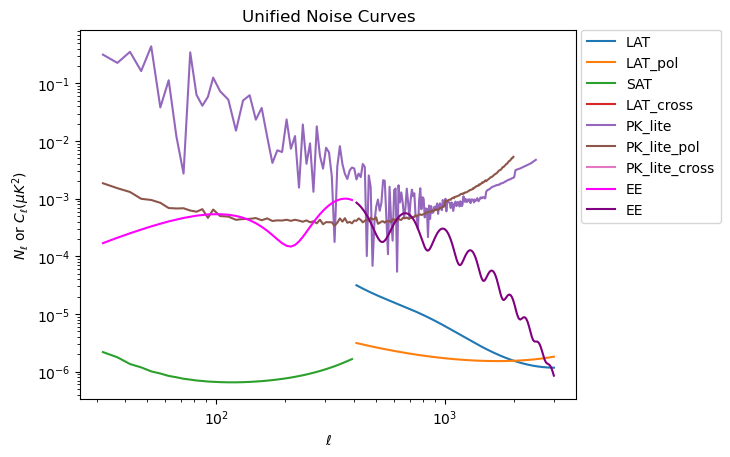

In [290]:
dict_temp = so_lik_unif['data']
for exp in dict_temp.keys():
    if isinstance(dict_temp[exp]['n_ell'],int) == False:
        plt.plot(dict_temp[exp]['ell'],np.abs(dict_temp[exp]['n_ell']), label = exp)

plt.plot(so_lik_unif['data']['SAT']['ell'],so_lik_unif['data']['SAT']['c_ell'], label = 'EE',color = 'magenta')
plt.plot(so_lik_unif['data']['LAT_pol']['ell'],so_lik_unif['data']['LAT_pol']['c_ell'], label = 'EE',  color = 'purple')
'''
plt.plot(so_lik_unif['data']['LAT']['ell'],so_lik_unif['data']['LAT']['c_ell'], label = 'TT, LAT',color = 'grey')
if 'PK' in so_lik_unif['data'].keys():
    plt.plot(so_lik_unif['data']['PK']['ell'],so_lik_unif['data']['PK']['c_ell'], label = 'TT, PK',color = 'indigo')
#plt.plot(so_lik_unif['data']['PK_lite']['ell'],so_lik_unif['data']['PK_lite']['c_ell'], label = 'TT, PK_Lite',color = 'black')
'''
plt.ylabel(r'$N_\ell $ or $C_\ell (\mu K^2)$')
plt.xlabel(r'$\ell$')
plt.loglog()
plt.title('Unified Noise Curves')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.savefig('images/noise_unified_lite.png', dpi=300, bbox_inches='tight')

In [109]:
## OK VERY IMPORTANT : COMPARE C_l^TT between datasets to make sure it is right.
'''
ell_plot = so_lik_unif['data']['LAT']['ell']
pref = _make_pref(ell_plot)

plt.plot(ell_plot,pref * so_lik_unif['data']['LAT']['c_ell'], label = 'TT, LAT',color = 'grey')
if 'PK' in so_lik_unif['data'].keys():
    ell_plot = so_lik_unif['data']['PK']['ell']
    pref = _make_pref(ell_plot)
    plt.plot(ell_plot, pref * so_lik_unif['data']['PK']['c_ell'], label = 'TT, PK',color = 'indigo')
    
ell_plot = so_lik_unif['data']['PK_lite']['ell']
pref = _make_pref(ell_plot)
plt.plot(ell_plot, pref * so_lik_unif['data']['PK_lite']['c_ell'], label = 'TT, PK_Lite',color = 'black')

ell_plot = cmb_theo_dict['ell']
pref = _make_pref(ell_plot)
plt.plot(ell_plot, pref * cmb_theo_dict['TT'], label = 'TT, Classy',color = 'orange')

plt.legend()
#plt.loglog()
plt.ylabel(r'$D_\ell$')
plt.title('Lite vs Classy Comparison (Difference comes from n_s mismatch)')
'''

<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_469547/1505498181.py:22: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel(r'$D_\ell$')


"\nell_plot = so_lik_unif['data']['LAT']['ell']\npref = _make_pref(ell_plot)\n\nplt.plot(ell_plot,pref * so_lik_unif['data']['LAT']['c_ell'], label = 'TT, LAT',color = 'grey')\nif 'PK' in so_lik_unif['data'].keys():\n    ell_plot = so_lik_unif['data']['PK']['ell']\n    pref = _make_pref(ell_plot)\n    plt.plot(ell_plot, pref * so_lik_unif['data']['PK']['c_ell'], label = 'TT, PK',color = 'indigo')\n\nell_plot = so_lik_unif['data']['PK_lite']['ell']\npref = _make_pref(ell_plot)\nplt.plot(ell_plot, pref * so_lik_unif['data']['PK_lite']['c_ell'], label = 'TT, PK_Lite',color = 'black')\n\nell_plot = cmb_theo_dict['ell']\npref = _make_pref(ell_plot)\nplt.plot(ell_plot, pref * cmb_theo_dict['TT'], label = 'TT, Classy',color = 'orange')\n\nplt.legend()\n#plt.loglog()\nplt.ylabel(r'$D_\\ell$')\nplt.title('Lite vs Classy Comparison (Difference comes from n_s mismatch)')\n"

/tmp/ipykernel_469547/2334919624.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


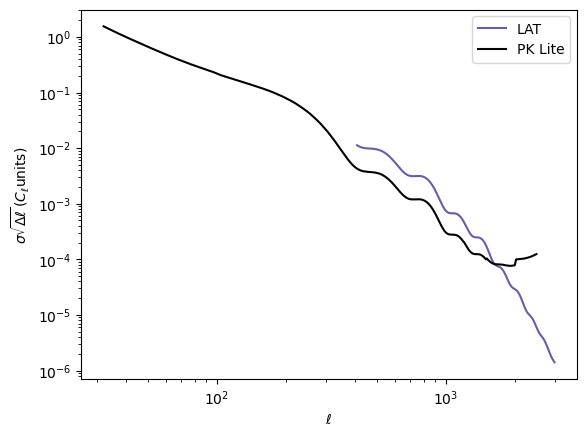

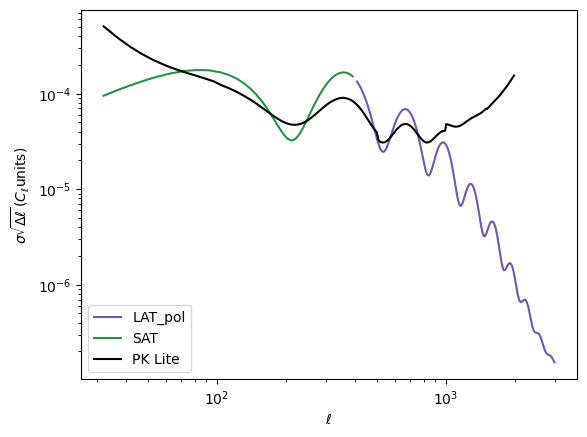

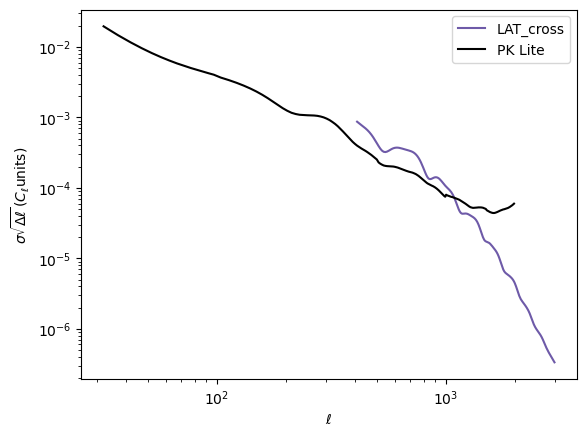

In [249]:
color_families = {
    'PK':       'Blues',
    'PK_pol':   'Blues',
    'PK_cross': 'Blues',
    'SAT':      'Greens',
    'LAT':      'Purples',
    'LAT_pol':  'Purples',
    'LAT_cross':'Purples',
}

def raw_EE_func(so_lik_unif, pref=False):
    if pref:
        fac = np.sqrt(1/(2*so_lik_unif['data']['SAT']['ell']+1))
    else:
        fac = 1
    plt.plot(so_lik_unif['data']['SAT']['ell'], fac * so_lik_unif['data']['SAT']['c_ell'],
             color='magenta')
    if pref:
        fac = np.sqrt(1/(2*so_lik_unif['data']['LAT_pol']['ell']+1))
    else:
        fac = 1
    plt.plot(so_lik_unif['data']['LAT_pol']['ell'], fac * so_lik_unif['data']['LAT_pol']['c_ell'],
             label='raw EE', color='purple')

def plot_cov(exp_temp_arr, cell_type, lite_data=lite_data, pref=False, raw_EE=False):
    for exp_temp in exp_temp_arr:
        cmap_name = color_families.get(exp_temp, 'Greys')
        color     = get_colors(5, cmap_name)[3]

        dict_temp = so_lik_unif['data'][exp_temp]
        ell_plot  = dict_temp['ell']
        err       = np.sqrt(dict_temp['cov'] * dict_temp['dell'])
        #err       = np.sqrt(dict_temp['cov'])


        if pref:
            err *= (ell_plot*(ell_plot+1)/2/np.pi)

        plt.plot(ell_plot, err, label=exp_temp, color=color)

    if raw_EE:
        raw_EE_func(so_lik_unif)

    err_lite = np.sqrt(lite_data[cell_type]['cov'] * lite_data[cell_type]['dell'])
    ell_lite = lite_data[cell_type]['ell']
    if pref:
        err_lite *= (ell_lite*(ell_lite+1)/2/np.pi)
    plt.plot(ell_lite, err_lite, label='PK Lite', color='black')

    ylabel = (r"$\sigma \sqrt{\Delta \ell} \, (D_{\ell} units)$" if pref
              else r'$\sigma \sqrt{\Delta \ell} \, (C_{\ell} $units)')
    plt.ylabel(ylabel)
    plt.xlabel(r'$\ell$')
    #plt.title('Comparison for {}'.format(cell_type))
    plt.loglog()
    plt.legend()
    #plt.savefig('images/cov_diag_{}.png'.format(cell_type), dpi=300, bbox_inches='tight')
    plt.show()

WITH_PK = False
if WITH_PK:
    plot_cov(['PK', 'LAT'], 'TT')
    plot_cov(['PK_pol', 'LAT_pol', 'SAT'], 'EE', raw_EE=False)
    plot_cov(['PK_cross', 'LAT_cross'], 'TE')
else:
    plot_cov(['LAT'], 'TT')
    plot_cov(['LAT_pol', 'SAT'],'EE', raw_EE=False)
    plot_cov(['LAT_cross'],'TE')

### making the final versison of the Covariance matrix using all of my datasets;
    - should I do SAT + LAT??
    - does ACT come in at any point??=> I should ask Jo.

In [250]:
def make_best_per_bin(so_lik_unif, ell_scheme, add_lite=True):
    '''
    For each polarization type (TT, EE, TE), selects at each ell bin the
    experiment with the smallest sigma * sqrt(dell). The ell grid is built
    in two parts:
      - within the PK Lite range: use the scheme bin centers directly,
        guaranteeing alignment across all polarization types
      - beyond the PK Lite range: take the union of whatever experiments
        extend that far, per polarization type
    All three polarization types are trimmed to their common ell intersection
    before returning, so TT, TE, EE always have the same size and bin centers.
    Returns a dict with keys 'TT', 'TE', 'EE'.
    '''
    if add_lite:
        exp_types = {
            'TT': ['PK', 'LAT', 'PK_lite'],
            'EE': ['PK_pol', 'LAT_pol', 'SAT', 'PK_lite_pol'],
            'TE': ['PK_cross', 'LAT_cross', 'PK_lite_cross'],
        }
    else:
        exp_types = {
            'TT': ['PK', 'LAT'],
            'EE': ['PK_pol', 'LAT_pol', 'SAT'],
            'TE': ['PK_cross', 'LAT_cross'],
        }

    # reference ell grid from PK Lite scheme (same for TT, TE, EE)
    ell_lite_ref = ell_scheme['TT']['ell']
    lmax_lite    = ell_lite_ref.max()

    out = {'metadata': deepcopy(so_lik_unif['metadata']),
           'data': {}}

    for cell_type, instruments in exp_types.items():

        available = [inst for inst in instruments if inst in so_lik_unif['data']]

        if len(available) == 0:
            continue

        # within PK Lite range: use scheme bin centers directly
        ell_in_range = ell_lite_ref.copy()

        # beyond PK Lite range: union of experiments that extend there
        ext_arrays = [
            so_lik_unif['data'][inst]['ell'][so_lik_unif['data'][inst]['ell'] > lmax_lite]
            for inst in available
            if len(so_lik_unif['data'][inst]['ell'][so_lik_unif['data'][inst]['ell'] > lmax_lite]) > 0
        ]
        ell_ext    = np.unique(np.concatenate(ext_arrays)) if ext_arrays else np.array([])
        ell_global = np.concatenate([ell_in_range, ell_ext])

        c_ell_best  = np.full(len(ell_global), np.nan)
        n_ell_best  = np.full(len(ell_global), np.nan)
        cov_best    = np.full(len(ell_global), np.nan)
        dell_best   = np.full(len(ell_global), np.nan)
        sigma_best  = np.full(len(ell_global), np.inf)
        source_best = np.full(len(ell_global), '', dtype=object)

        for inst in available:
            d     = so_lik_unif['data'][inst]
            ell_i = d['ell']
            sigma = np.sqrt(d['cov'] * d['dell'])

            for k, ell_val in enumerate(ell_global):
                idx = np.where(ell_i == ell_val)[0]
                if len(idx) == 0:
                    continue
                idx = idx[0]
                if sigma[idx] < sigma_best[k]:
                    sigma_best[k]  = sigma[idx]
                    c_ell_best[k]  = d['c_ell'][idx]
                    n_ell_best[k]  = d['n_ell'][idx]
                    cov_best[k]    = d['cov'][idx]
                    dell_best[k]   = d['dell'][idx]
                    source_best[k] = inst

        # mask out bins not covered by any experiment
        mask = ~np.isnan(c_ell_best)
        out['data'][cell_type] = {
            'c_ell':  c_ell_best[mask],
            'n_ell':  n_ell_best[mask],
            'cov':    cov_best[mask],
            'dell':   dell_best[mask],
            'ell':    ell_global[mask],
            'source': source_best[mask],
        }

    # ── enforce common ell grid across TT, TE, EE ────────────────────────────
    # different polarization types may have different extensions beyond lmax_lite
    # so we take the intersection to guarantee identical size and bin centers
    present = [p for p in ('TT', 'TE', 'EE') if p in out['data']]
    if len(present) > 1:
        ell_common = set(out['data'][present[0]]['ell'])
        for pol in present[1:]:
            ell_common &= set(out['data'][pol]['ell'])
        ell_common = np.array(sorted(ell_common))

        for pol in present:
            mask = np.isin(out['data'][pol]['ell'], ell_common)
            out['data'][pol] = {k: v[mask] for k, v in out['data'][pol].items()}

    return out

In [251]:
so_lik_best = make_best_per_bin(so_lik_unif, ell_scheme)

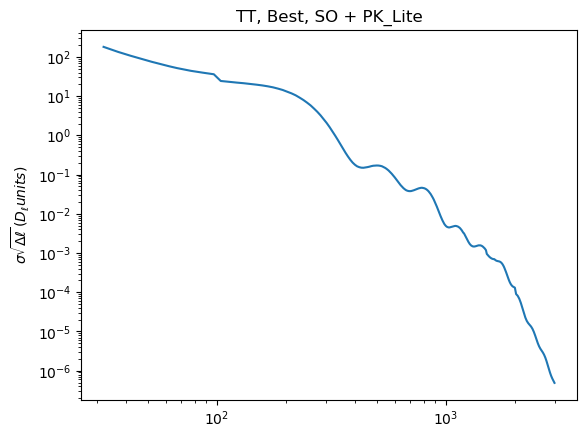

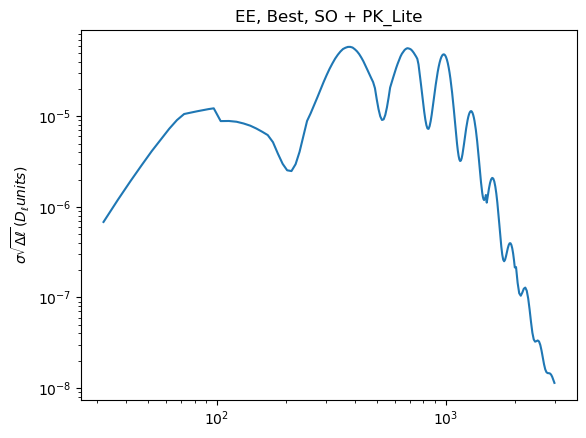

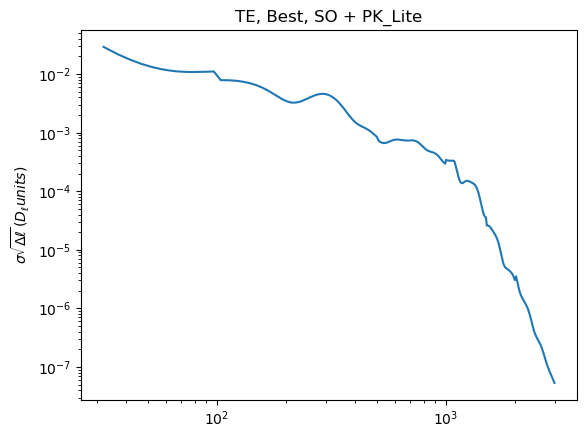

In [252]:
metadata = so_lik_best['metadata']
tt = so_lik_best['data']['TT']
te = so_lik_best['data']['TE']
ee = so_lik_best['data']['EE']

ell  = tt['ell']
dell  = tt['dell']
pref = _make_pref(ell)

err_tt = so_lik_best['data']['TT']['cov']
err_te = so_lik_best['data']['TE']['cov']
err_ee = so_lik_best['data']['EE']['cov']

fsky_tt = np.array([metadata[src]['fsky'] for src in tt['source']])
fsky_te = np.array([metadata[src]['fsky'] for src in te['source']])
fsky_ee = np.array([metadata[src]['fsky'] for src in ee['source']])

#plt.errorbar(ell, pref * (tt['c_ell'] + tt['n_ell']), yerr =  pref * tt['cov'], linestyle = )
plt.loglog(ell, pref *err_tt * np.sqrt(dell))
plt.ylabel(r"$\sigma \sqrt{\Delta \ell} \, (D_{\ell} units)$")
plt.title('TT, Best, SO + PK_Lite')
plt.show()

plt.loglog(ell, pref *err_ee * np.sqrt(dell))
plt.ylabel(r"$\sigma \sqrt{\Delta \ell} \, (D_{\ell} units)$")
plt.title('EE, Best, SO + PK_Lite')
plt.show()

plt.loglog(ell, pref *err_te * np.sqrt(dell))
plt.ylabel(r"$\sigma \sqrt{\Delta \ell} \, (D_{\ell} units)$")
plt.title('TE, Best, SO + PK_Lite')
plt.show()

In [253]:
def make_ttteee_cov(so_lik_best):
    '''
    Builds a block-diagonal TTTEEE covariance matrix of shape (3N, 3N) where
    N is the number of ell bins. Each of the 9 blocks is diagonal, filled
    according to the Gaussian (Knox) covariance formula.

    Block ordering: [TT | TE | EE]

    fsky is extracted per bin from the metadata using the source array.
    '''
    metadata = so_lik_best['metadata']
    tt = so_lik_best['data']['TT']
    te = so_lik_best['data']['TE']
    ee = so_lik_best['data']['EE']

    ell  = tt['ell']
    dell = tt['dell']

    # extract per-bin fsky directly from metadata using the source array
    fsky_tt = np.array([metadata[src]['fsky'] for src in tt['source']])
    fsky_te = np.array([metadata[src]['fsky'] for src in te['source']])
    fsky_ee = np.array([metadata[src]['fsky'] for src in ee['source']])

    # use the most conservative fsky at each bin across all three
    fsky = np.minimum(fsky_tt, np.minimum(fsky_te, fsky_ee))

    # total spectra
    ctt = tt['c_ell'] + tt['n_ell']
    cee = ee['c_ell'] + ee['n_ell']
    cte = te['c_ell']   # TE has no noise bias

    prefactor_auto  = 2.0 / (2.0 * ell + 1.0) / dell / fsky
    prefactor_cross = 1.0 / (2.0 * ell + 1.0) / dell / fsky

    # ── diagonal of each block ────────────────────────────────────────────────
    cov_tt_tt = prefactor_auto  * ctt**2
    cov_ee_ee = prefactor_auto  * cee**2
    cov_te_te = prefactor_cross * (cte**2 + ctt * cee)
    cov_tt_ee = prefactor_auto  * cte**2
    cov_tt_te = prefactor_auto  * cte * ctt
    cov_ee_te = prefactor_auto  * cte * cee

    # ── assemble the 3N x 3N matrix ───────────────────────────────────────────
    N   = len(ell)
    cov = np.zeros((3 * N, 3 * N))

    idx_tt = slice(0,     N)
    idx_te = slice(N,   2*N)
    idx_ee = slice(2*N, 3*N)

    np.fill_diagonal(cov[idx_tt, idx_tt], cov_tt_tt)
    np.fill_diagonal(cov[idx_te, idx_te], cov_te_te)
    np.fill_diagonal(cov[idx_ee, idx_ee], cov_ee_ee)

    np.fill_diagonal(cov[idx_tt, idx_ee], cov_tt_ee)
    np.fill_diagonal(cov[idx_ee, idx_tt], cov_tt_ee)

    np.fill_diagonal(cov[idx_tt, idx_te], cov_tt_te)
    np.fill_diagonal(cov[idx_te, idx_tt], cov_tt_te)

    np.fill_diagonal(cov[idx_ee, idx_te], cov_ee_te)
    np.fill_diagonal(cov[idx_te, idx_ee], cov_ee_te)

    return cov

ASK JO: HOW TO HANDLE FSKY FOR OFF-DIAGONAL BLOCKS?

In [254]:
ttteee_cov = make_ttteee_cov(so_lik_best)

### 3. Fisher Forecasting

In [255]:
from fisher import (
    SpectrumBand,
    FisherResult,
    fisher_forecast,
    compute_dC_bands,
    _step_for,
    _perturb,
    parse_spectrum_bands,
    eval_cls_on_bands,
    plot_save_suite,
)

def parse_bands_from_best(so_lik_best):
    '''
    Parse so_lik_best into a flat list of SpectrumBand objects for use with
    fisher_forecast. Creates one band per polarization type (TT, TE, EE),
    using the already-computed diagonal covariance from make_best_per_bin.

    The cov stored in so_lik_best already encodes Var(C_hat_ell) with fsky,
    so no further weighting is needed in fisher_forecast.
    '''
    metadata = so_lik_best['metadata']
    bands    = []

    for cell_type in ('TT', 'TE', 'EE'):
        d = so_lik_best['data'][cell_type]

        # use the most conservative fsky across the bins as a scalar summary
        fsky = min(metadata[src]['fsky'] for src in np.unique(d['source']))

        bands.append(SpectrumBand(
            exp_key   = f'best_{cell_type}',
            channel   = f'best_{cell_type}',
            cell_type = cell_type,
            ell       = d['ell'].astype(int),
            dell      = d['dell'],
            fsky      = fsky,
            cov       = d['cov'],
        ))

    return bands


def fisher_forecast_ttteee(
    theta0:        dict,
    param_list:    list,
    so_lik_best:   dict,
    compute_cls:   callable,
    steps:         dict,
    scaled_params: set  = frozenset(),
    ell_max:       int  = 10_000,
    use_pinv:      bool = False,
) -> FisherResult:
    '''
    Fisher forecast using the full TTTEEE covariance matrix (with off-diagonal
    TT-TE, TT-EE, EE-TE blocks), computed via make_ttteee_cov.

    At each ell bin b, the 3-vector dC_α(b) = [dC_TT/dθ_α, dC_TE/dθ_α, dC_EE/dθ_α]
    is formed, and the contribution to F_αβ is:

        dC_α(b)^T · C_3x3^{-1}(b) · dC_β(b)

    where C_3x3(b) is the 3x3 covariance block at bin b from make_ttteee_cov.

    Parameters
    ----------
    theta0       : fiducial parameter dict
    param_list   : parameters to forecast
    so_lik_best  : output of make_best_per_bin (with metadata)
    compute_cls  : callable(**theta, lmax=int) -> {cell_type: Cl_array}
    steps        : step sizes keyed by param name
    scaled_params: params multiplied by 1e10 before differencing
    ell_max      : passed to compute_cls
    use_pinv     : use pseudo-inverse when inverting F
    '''
    # ── build full TTTEEE covariance and extract per-bin 3x3 blocks ──────────
    cov_full = make_ttteee_cov(so_lik_best)   # shape (3N, 3N)
    N        = len(so_lik_best['data']['TT']['ell'])

    # invert each 3x3 block independently — covariance is block-diagonal in ell
    cov_inv_blocks = np.zeros((N, 3, 3))
    for b in range(N):
        block = cov_full[np.ix_([b, b+N, b+2*N], [b, b+N, b+2*N])]
        cov_inv_blocks[b] = np.linalg.inv(block)

    # ell grids (all three are identical)
    ell_tt = so_lik_best['data']['TT']['ell'].astype(int)

    # compute derivatives from bands
    bands = parse_bands_from_best(so_lik_best)
    dC = []
    for param in param_list:
        step, _ = _step_for(param, steps, scaled_params)
        dC_p = compute_dC_bands(
            theta0        = theta0,
            param         = param,
            step          = step,
            bands         = bands,
            compute_cls   = compute_cls,
            scaled_params = scaled_params,
            ell_max       = ell_max,
        )
        # dC_p[0] = TT, dC_p[1] = TE, dC_p[2] = EE — stack into (N, 3)
        dC.append(np.stack([dC_p[0], dC_p[1], dC_p[2]], axis=1))
    # ── Fisher matrix ─────────────────────────────────────────────────────────
    npar = len(param_list)
    F    = np.zeros((npar, npar))

    for i in range(npar):
        for j in range(i, npar):
            # sum over ell bins: dC_i^T C^{-1} dC_j
            s = sum(
                dC[i][b] @ cov_inv_blocks[b] @ dC[j][b]
                for b in range(N)
            )
            F[i, j] = s
            F[j, i] = s

    # ── parameter covariance ──────────────────────────────────────────────────
    inv        = np.linalg.pinv if use_pinv else np.linalg.inv
    Cov_params = inv(F)
    sigma      = np.sqrt(np.diag(Cov_params))

    # package bands for compatibility with FisherResult
    bands = parse_bands_from_best(so_lik_best)

    return FisherResult(
        F          = F,
        Cov_params = Cov_params,
        sigma      = sigma,
        dC         = dC,
        bands      = bands,
        param_list = list(param_list),
    )

In [273]:
SCALED10_PARAMS = {"P_RR_1", "P_RR_2", "P_II_1", "P_II_2"}

param_list = [
    "omega_b", "omega_cdm", "h", "tau_reio",
    "P_RR_1", "P_RR_2", "P_II_1", "P_II_2"
]

steps_abs = {
    "omega_b": 2.5e-5,
    "omega_cdm": 1.5e-4,
    "h": 6.0e-4,
    "tau_reio": 6.0e-5,
}

steps_scaled10 = {
    "P_RR_1": 0.01,
    "P_RR_2": 0.01,
    "P_II_1": 0.05,
    "P_II_2": 0.05,
}


In [274]:
fisher_5yr = fisher_forecast_ttteee(
    theta0 = theta0,
    param_list = param_list ,
    so_lik_best = so_lik_best,
    compute_cls = compute_cls,
    steps = {**steps_abs, **steps_scaled10},
    scaled_params = SCALED10_PARAMS,
    ell_max = LMAX_FID,
    use_pinv = True,
)

In [275]:
def plot_save_suite(result, 
                    EXP_NAME,
                    theta_0,
                    scaled_params,
                    save_dir,
                   LATEX = {
                            "omega_b":   r"\omega_b",
                            "omega_cdm": r"\omega_{\rm cdm}",
                            "h":         r"h",
                            "tau_reio":  r"\tau",
                            "P_RR_1":    r"10^{10}P_{RR,1}",
                            "P_RR_2":    r"10^{10}P_{RR,2}",
                            "P_II_1":    r"10^{10}P_{II,1}",
                            "P_II_2":    r"10^{10}P_{II,2}",
                        },
                   ):
    table_savepath = "{}/sum_table_{}.png".format(save_dir,EXP_NAME)
    corrmat_savepath = "{}/corr_matrix_{}.png".format(save_dir,EXP_NAME)
    triangle_savepath = "{}/triangle_plot_{}.png".format(save_dir,EXP_NAME)
    
    result_now = deepcopy(result)
    
    df = result_now.save_summary_table(
        theta0=theta0, scaled_params=SCALED10_PARAMS,
        exp_name=EXP_NAME, save_path=table_savepath,
    )
    display(df)
    
    result_now.plot_correlation(exp_name=EXP_NAME, save_path=corrmat_savepath)
    
    result_now.plot_triangle(
        theta0=theta0, label_map=LATEX,
        scaled_params=SCALED10_PARAMS,
        exp_name=EXP_NAME, save_path=triangle_savepath,
    )


,Fiducial,sigma,S/N
omega_b,0.02237,0.000067,333.627599
omega_cdm,0.11933,0.000725,164.545133
h,0.67660,0.002954,229.022557
tau_reio,0.05610,0.009949,5.638512
P_RR_1,23.00000,0.461391,49.849255
P_RR_2,23.00000,0.435154,52.854848
P_II_1,10.00000,2.223870,4.496666
P_II_2,10.00000,2.442791,4.093678


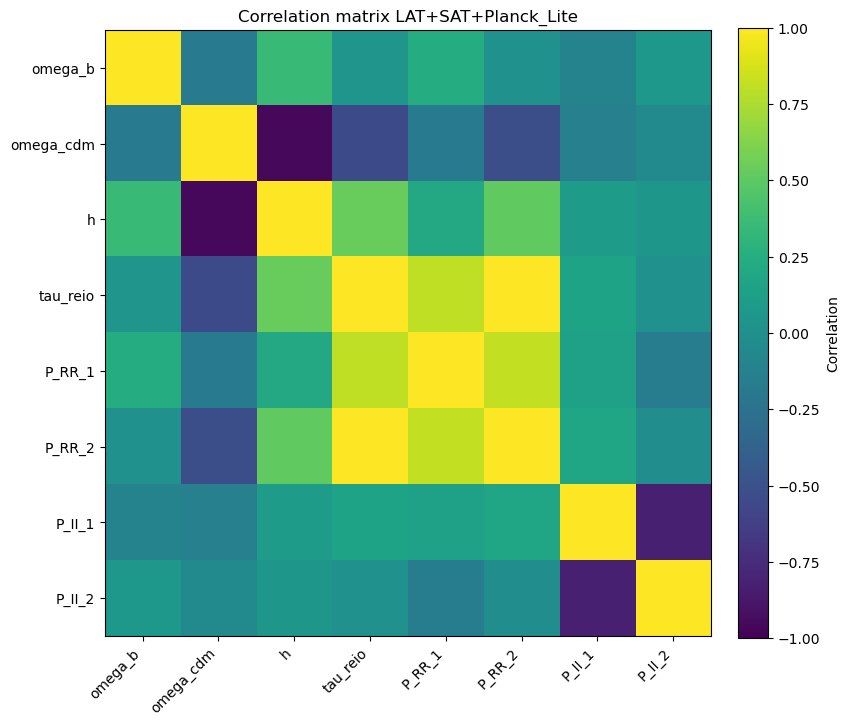

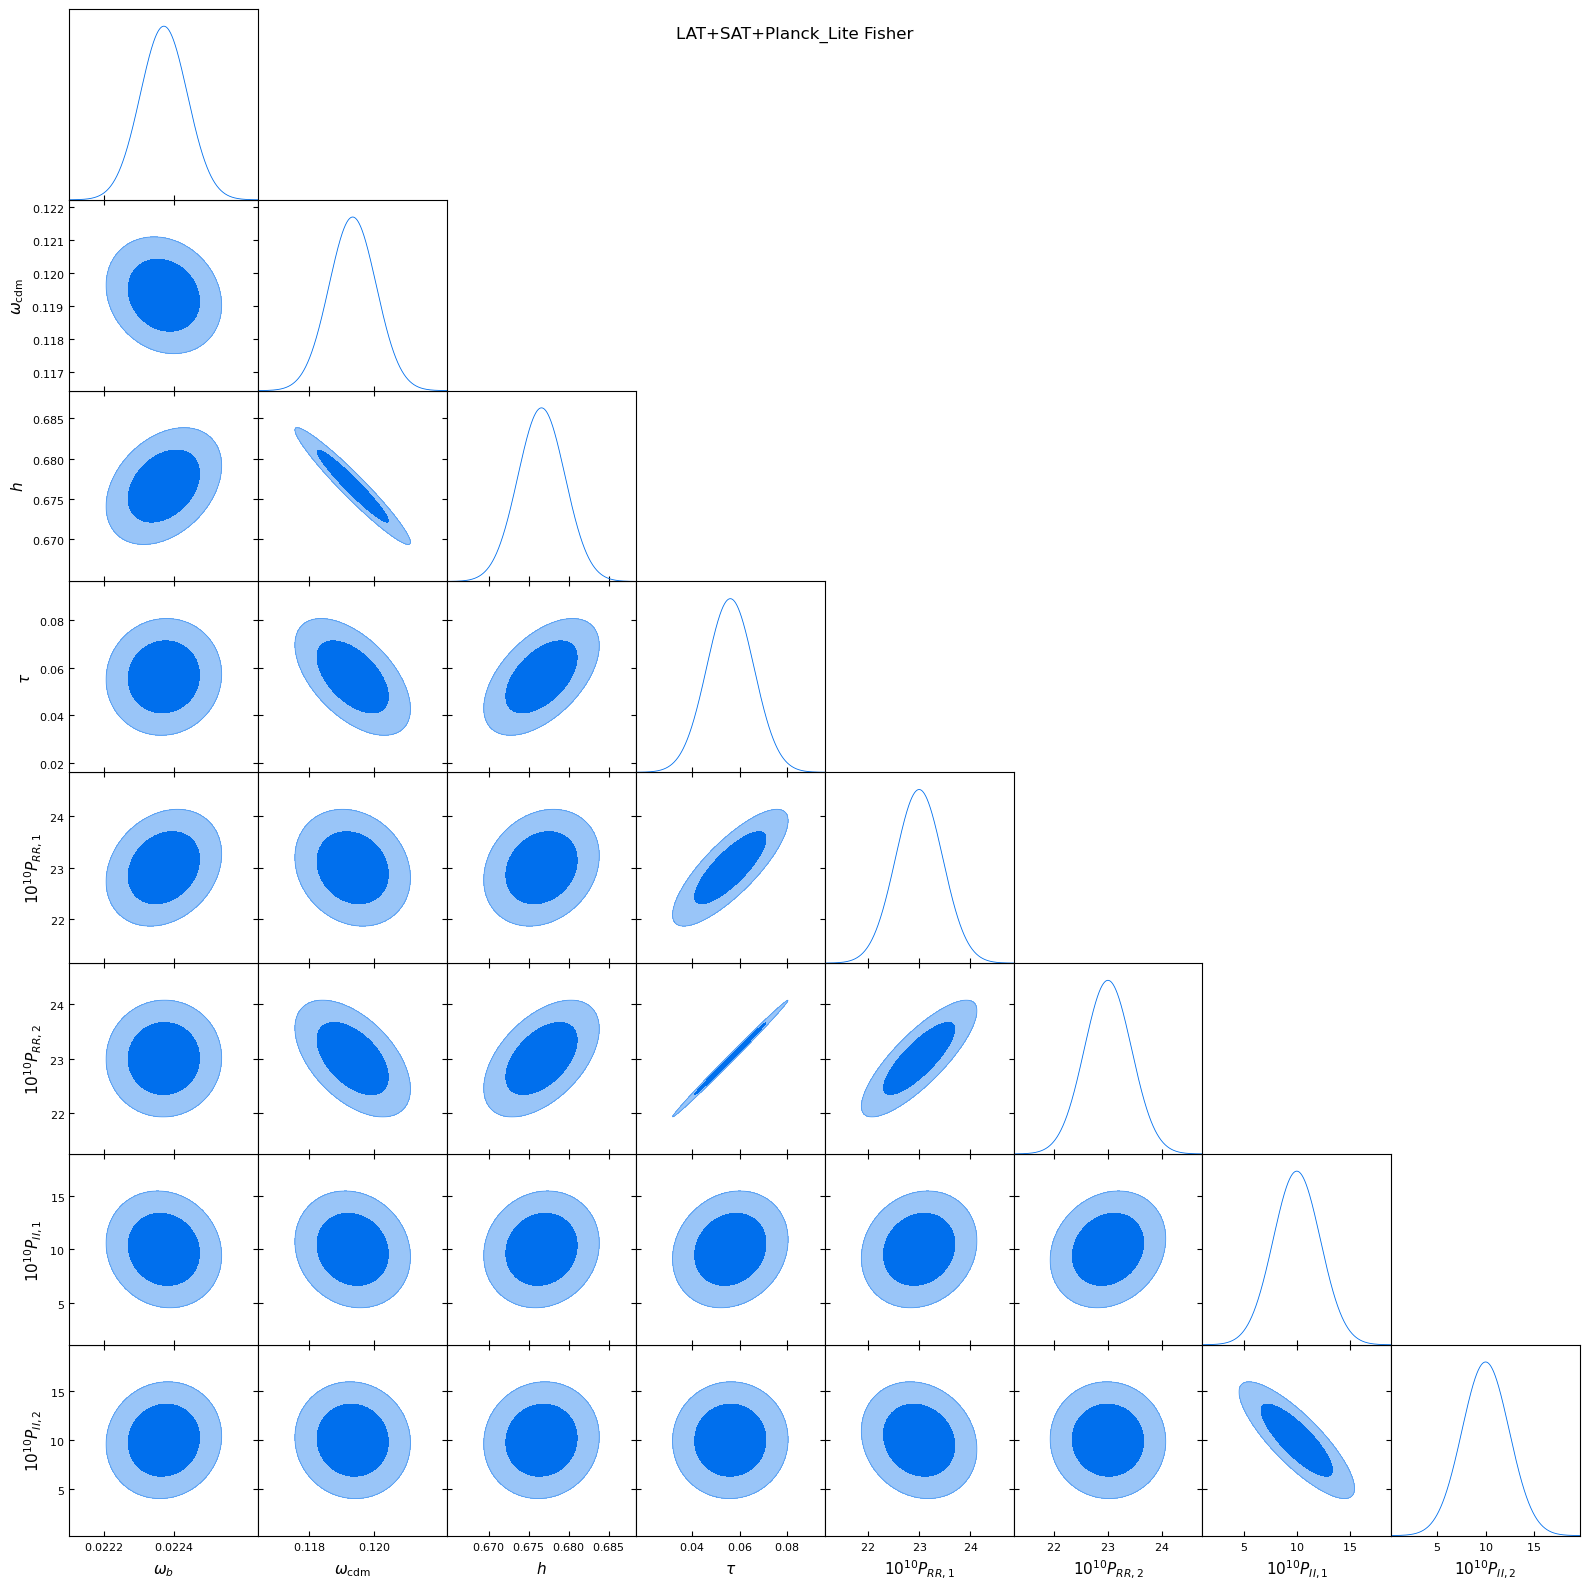

In [281]:
plot_save_suite(fisher_5yr,
                'SO+Planck_Lite',
               theta0,
               scaled_params = SCALED10_PARAMS,
               save_dir = 'images/040826_fisher')

final step is to make a wrapper function that runs the entire pipeline (from input to Fisher result) in one line

will do this for the 12 x 6 runs that I need to do! once Jo n Sussanna give me the thumbs up

In [282]:
# running the whole pipeline for LCDM+UCDI, it is sooo satisfying how easy it is:

out_lite = {
    'metadata': {},
    'data':{},
}
out_lite =  add_lite_to_out(out_lite,lite_data)
best_lite = make_best_per_bin(out_lite, ell_scheme)

fisher_lite = fisher_forecast_ttteee(
    theta0 = theta0,
    param_list = param_list ,
    so_lik_best = best_lite,
    compute_cls = compute_cls,
    steps = {**steps_abs, **steps_scaled10},
    scaled_params = SCALED10_PARAMS,
    ell_max = LMAX_FID,
    use_pinv = False,
)

,Fiducial,sigma,S/N
omega_b,0.02237,0.000129,173.076131
omega_cdm,0.11933,0.001235,96.644307
h,0.67660,0.005545,122.016984
tau_reio,0.05610,0.026654,2.104717
P_RR_1,23.00000,1.192776,19.282750
P_RR_2,23.00000,1.205837,19.073893
P_II_1,10.00000,1.601264,6.245065
P_II_2,10.00000,2.104313,4.752146


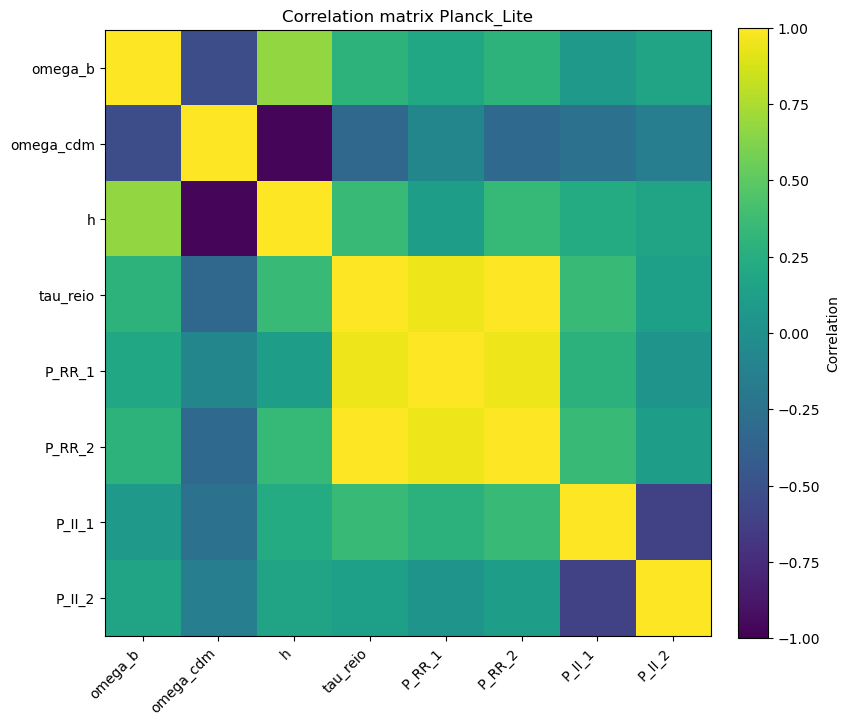

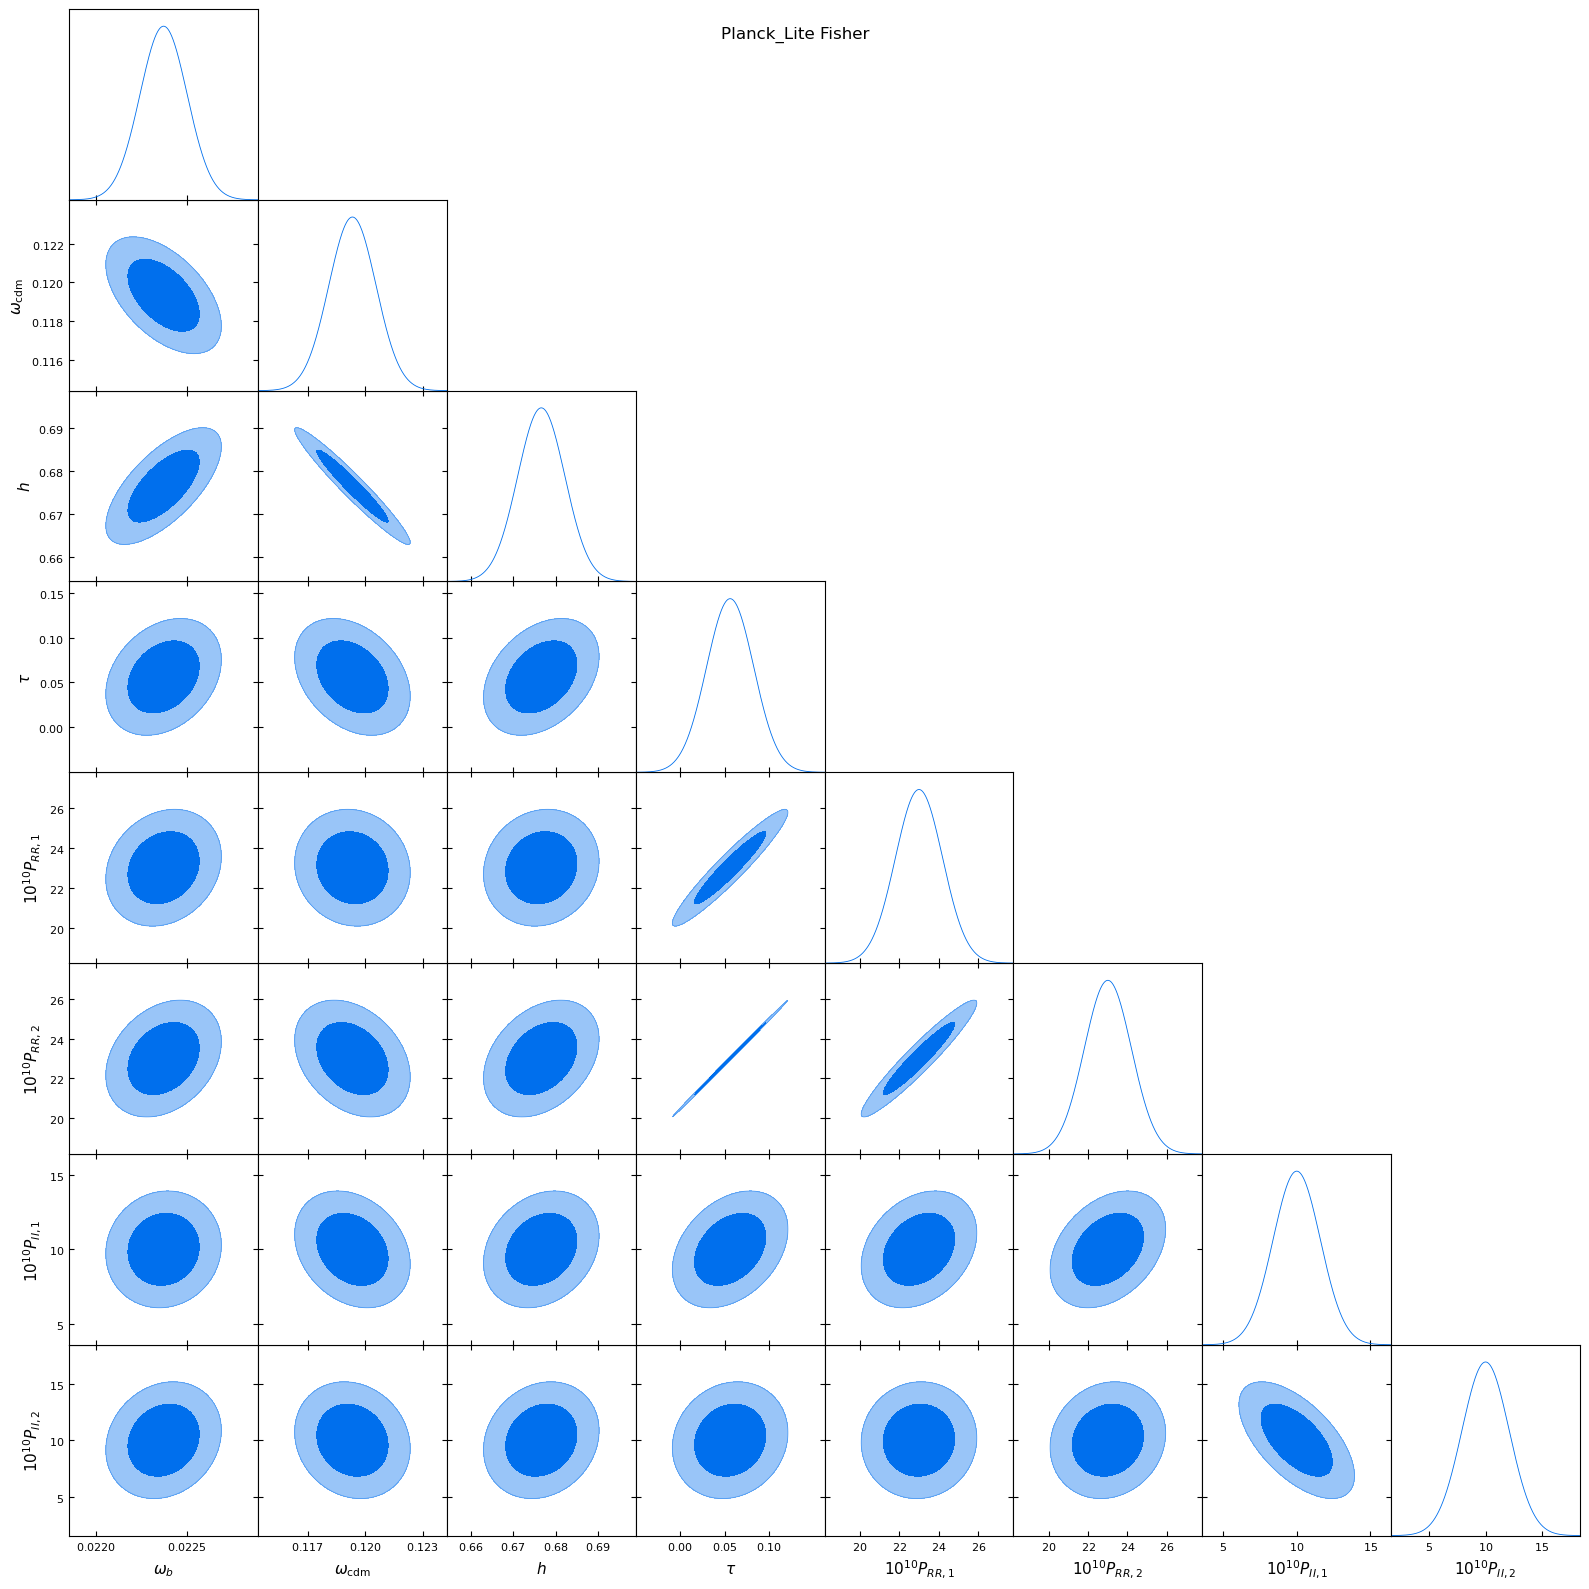

In [283]:
plot_save_suite(fisher_lite,
                'Planck_Lite',
               theta0,
               scaled_params = SCALED10_PARAMS,
               save_dir = 'images/040826_fisher')

In [284]:
def plot_fisher_comparison(results: dict[str, FisherResult],
                           theta0:        dict,
                           label_map:     dict = None,
                           scaled_params: set  = frozenset(),
                           save_path:     str  = None):
    '''
    Plot multiple FisherResult objects on the same triangle/corner plot.

    Parameters
    ----------
    results      : dict mapping a label string to a FisherResult
    theta0       : fiducial parameter dict
    label_map    : optional LaTeX labels for parameters
    scaled_params: params shown in ×1e10 space
    save_path    : if given, save the figure there
    '''
    from getdist.gaussian_mixtures import GaussianND
    from getdist import plots

    label_map = label_map or {}

    # all results must share the same param_list
    param_lists = [r.param_list for r in results.values()]
    if not all(p == param_lists[0] for p in param_lists):
        raise ValueError("All FisherResult objects must have the same param_list.")

    param_list = param_lists[0]
    labels     = [label_map.get(p, p) for p in param_list]

    centers = np.array(
        [1e10 * theta0[p] if p in scaled_params else theta0[p]
         for p in param_list],
        dtype=float,
    )

    gaussians = []
    names     = []
    for name, result in results.items():
        g = GaussianND(centers, result.Cov_params,
                       names=param_list, labels=labels)
        gaussians.append(g)
        names.append(name)

    g = plots.get_subplot_plotter()
    g.triangle_plot(gaussians, param_list, filled=True, legend_labels=names)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return g

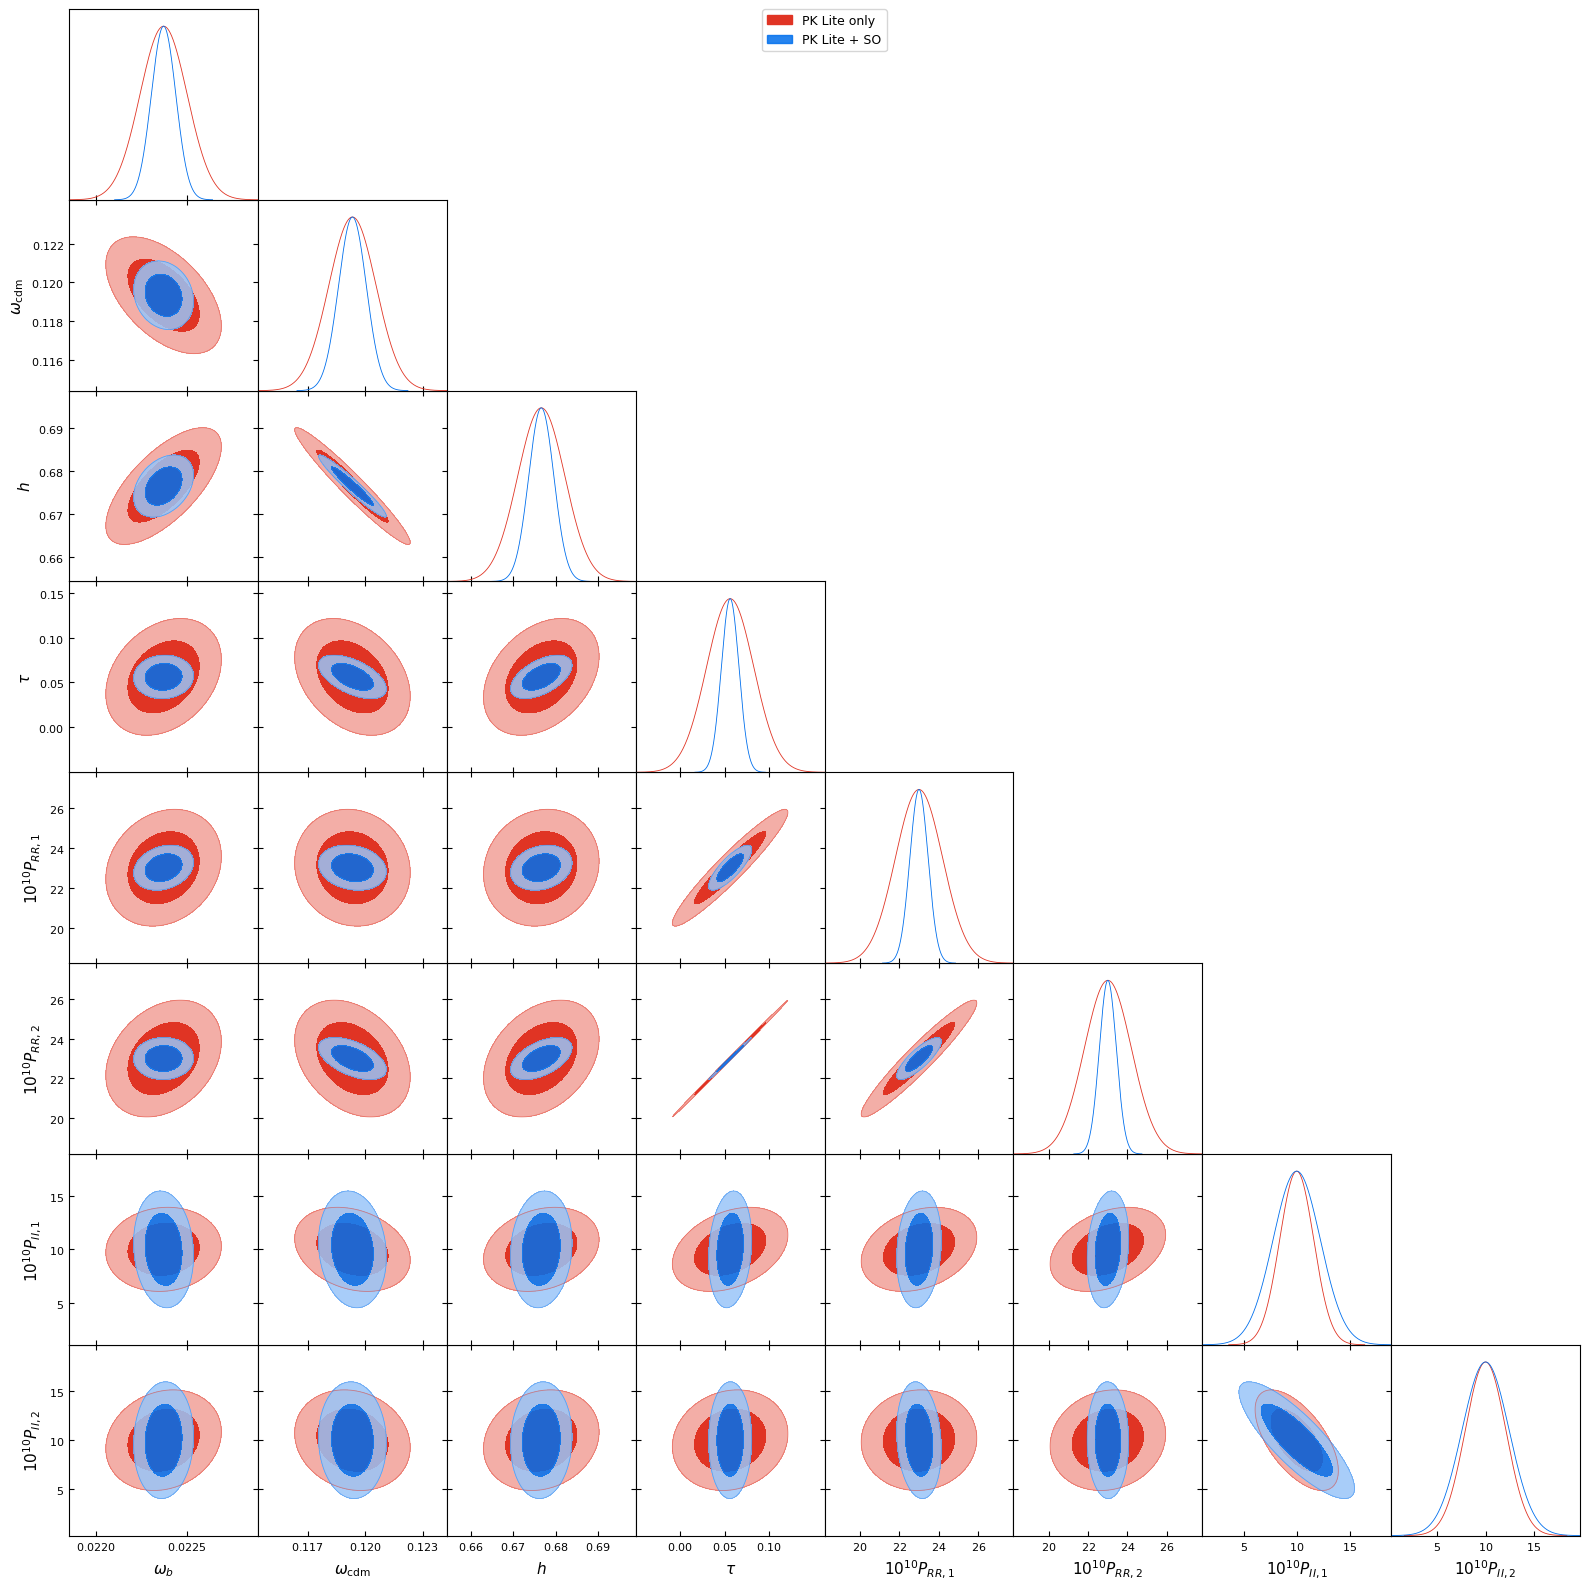

In [285]:
LATEX = {
                            "omega_b":   r"\omega_b",
                            "omega_cdm": r"\omega_{\rm cdm}",
                            "h":         r"h",
                            "tau_reio":  r"\tau",
                            "P_RR_1":    r"10^{10}P_{RR,1}",
                            "P_RR_2":    r"10^{10}P_{RR,2}",
                            "P_II_1":    r"10^{10}P_{II,1}",
                            "P_II_2":    r"10^{10}P_{II,2}",
                        }

plot_fisher_comparison(
    results       = {'PK Lite only': fisher_lite,'PK Lite + SO': fisher_5yr},
    theta0        = theta0,
    label_map     = LATEX,
    scaled_params = {'P_RR_1', 'P_RR_2', 'P_II_1', 'P_II_2'},
    save_path     = 'images/040826_fisher/fisher_comparison.png',
)

### TRYING DIFFERENT STEP SIZES (need to check my covariance again, but this is the only thing I can think of)

,Fiducial,sigma,S/N
omega_b,0.02237,0.000056,399.957424
omega_cdm,0.11933,0.000819,145.678337
h,0.67660,0.003311,204.373711
tau_reio,0.05610,0.008818,6.361860
P_RR_1,23.00000,0.394995,58.228520
P_RR_2,23.00000,0.387257,59.392148
P_II_1,10.00000,0.996066,10.039496
P_II_2,10.00000,1.056064,9.469124


,Fiducial,sigma,S/N
omega_b,0.02237,0.000041,549.743231
omega_cdm,0.11933,0.000685,174.285050
h,0.67660,0.002653,255.041023
tau_reio,0.05610,0.006027,9.308763
P_RR_1,23.00000,0.176771,130.111702
P_RR_2,23.00000,0.256894,89.531031
P_II_1,10.00000,1.095457,9.128610
P_II_2,10.00000,1.103828,9.059382


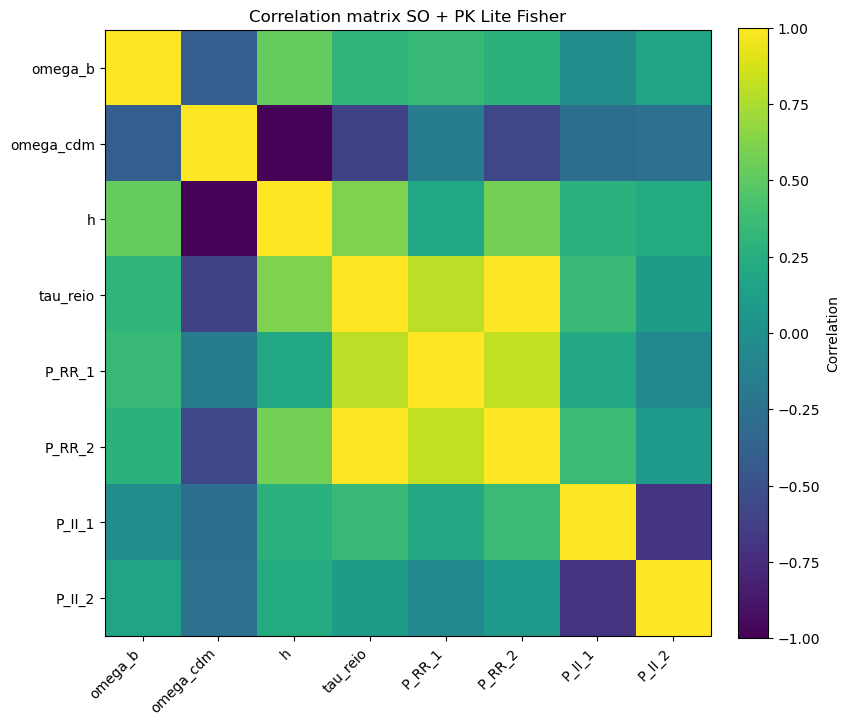

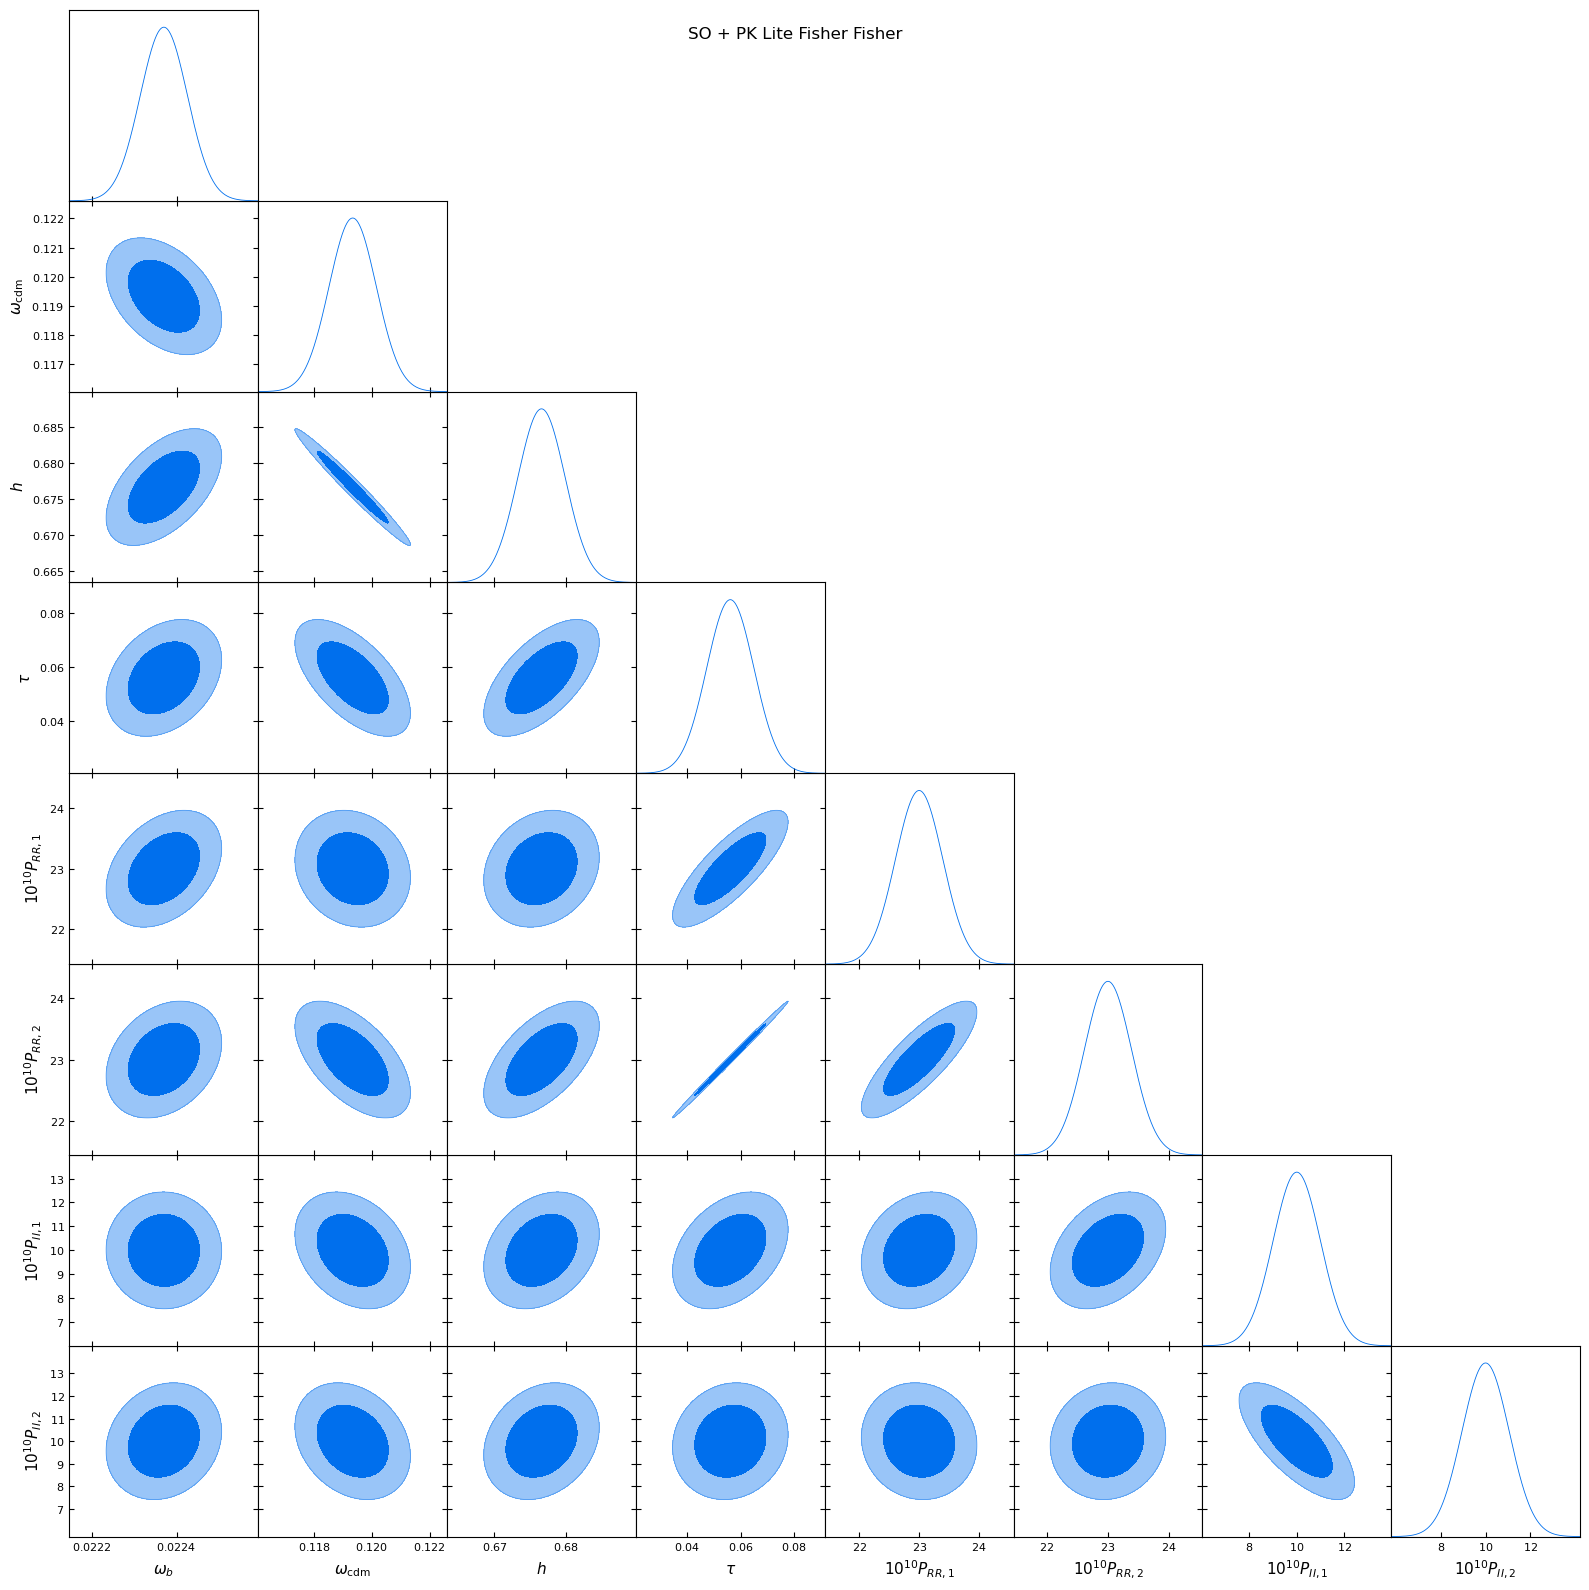

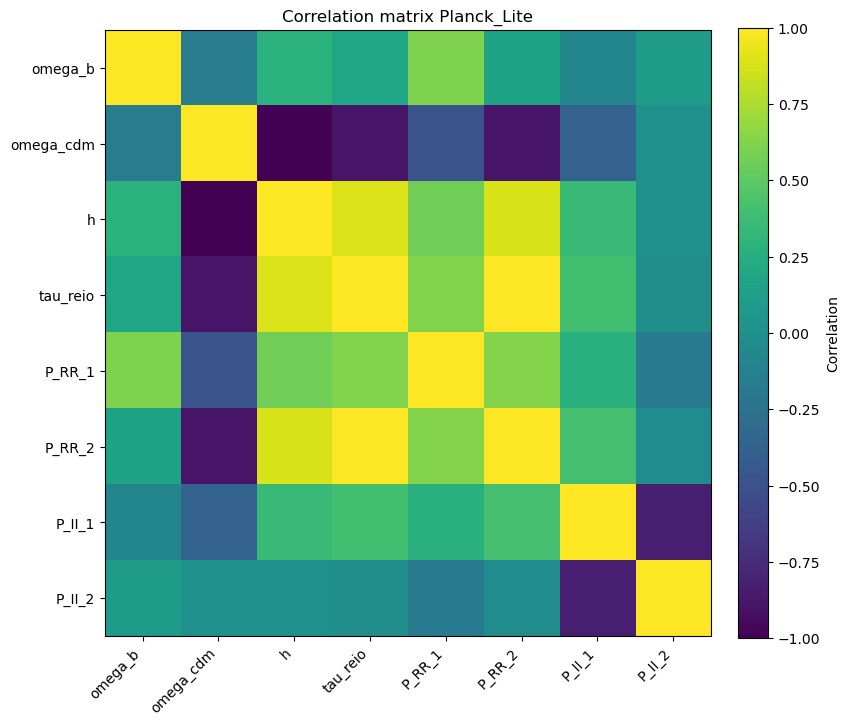

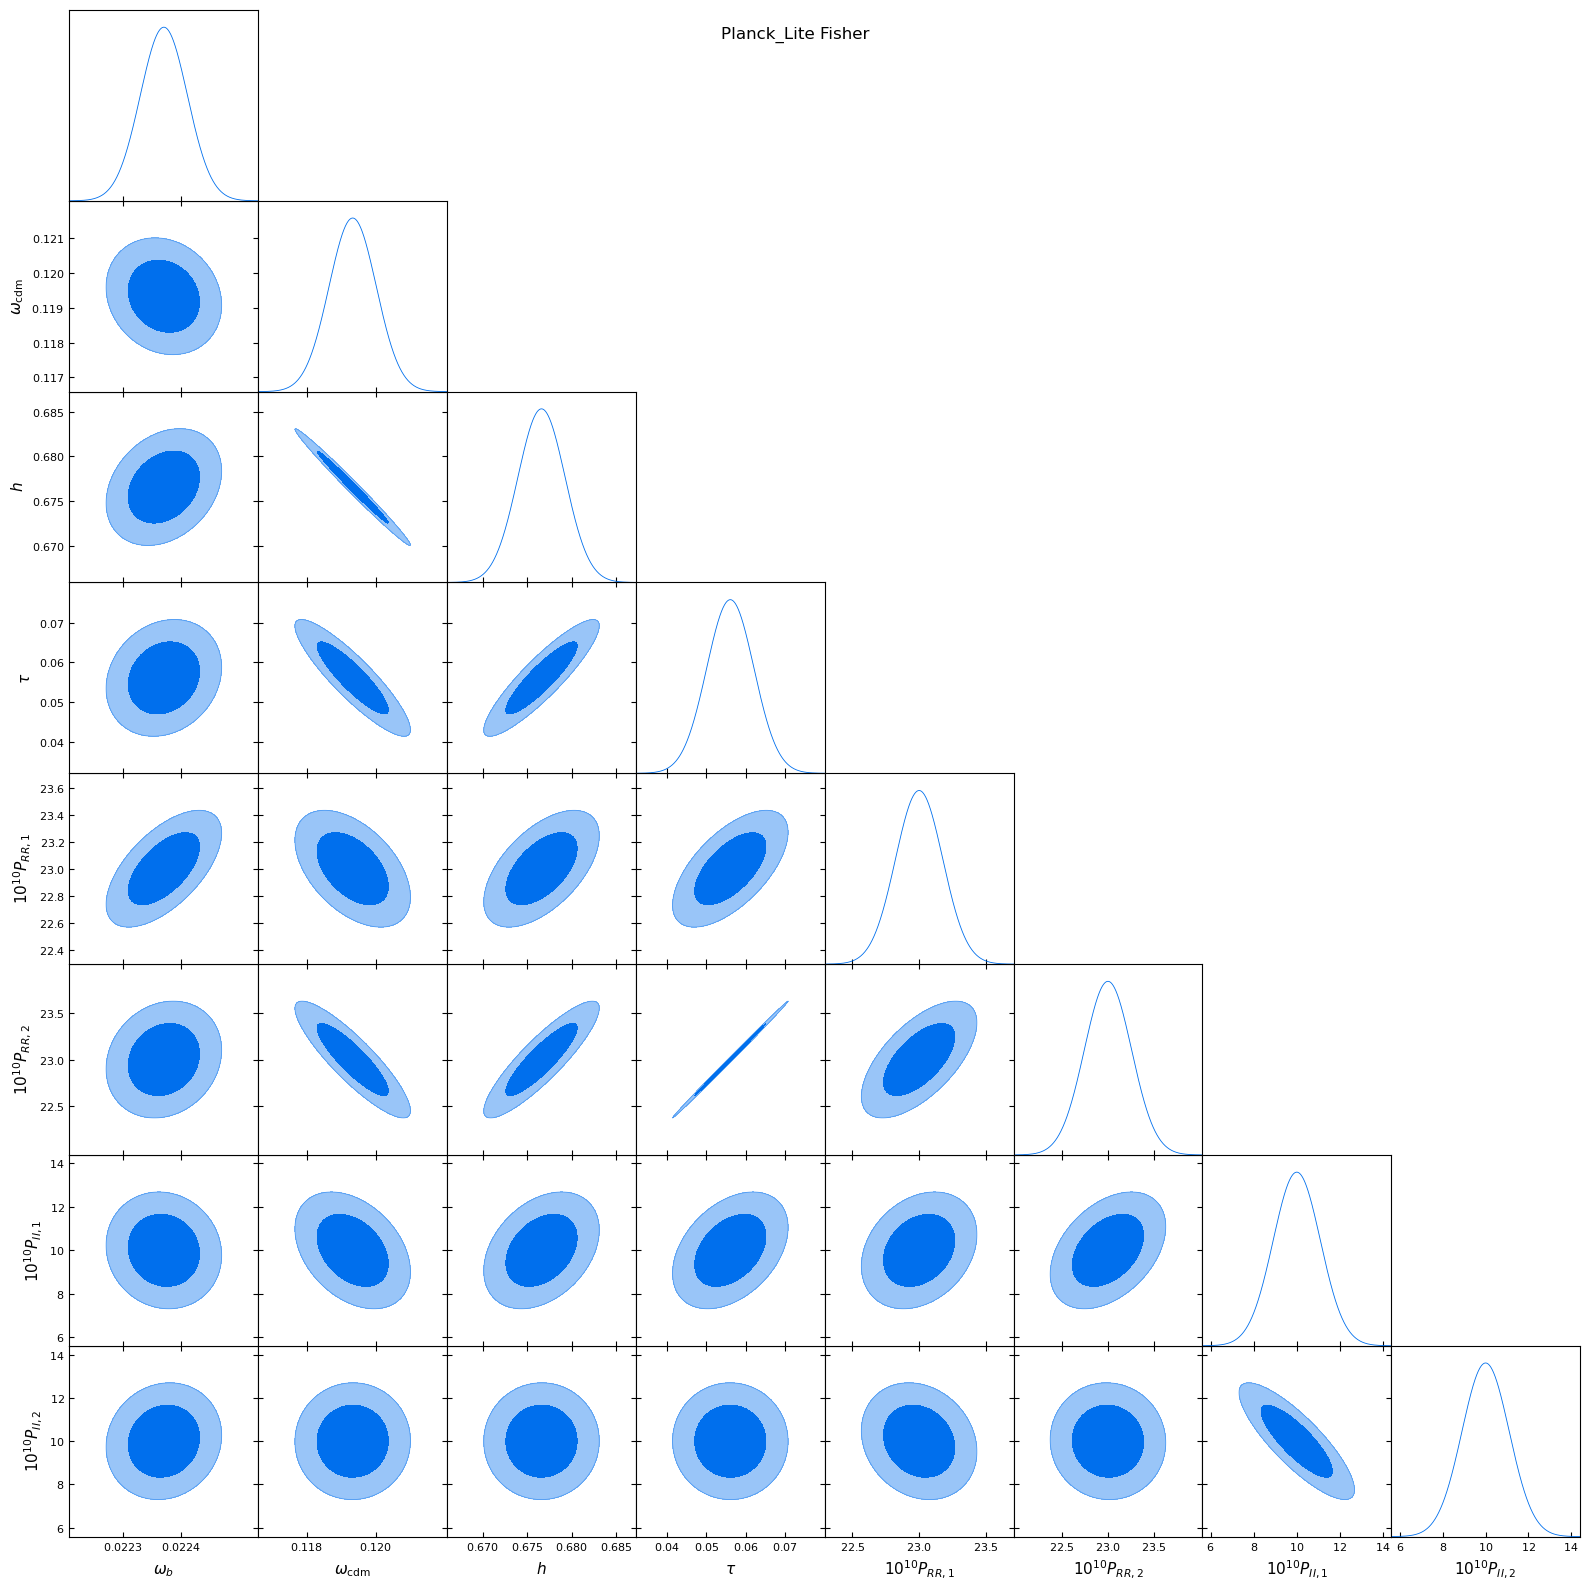

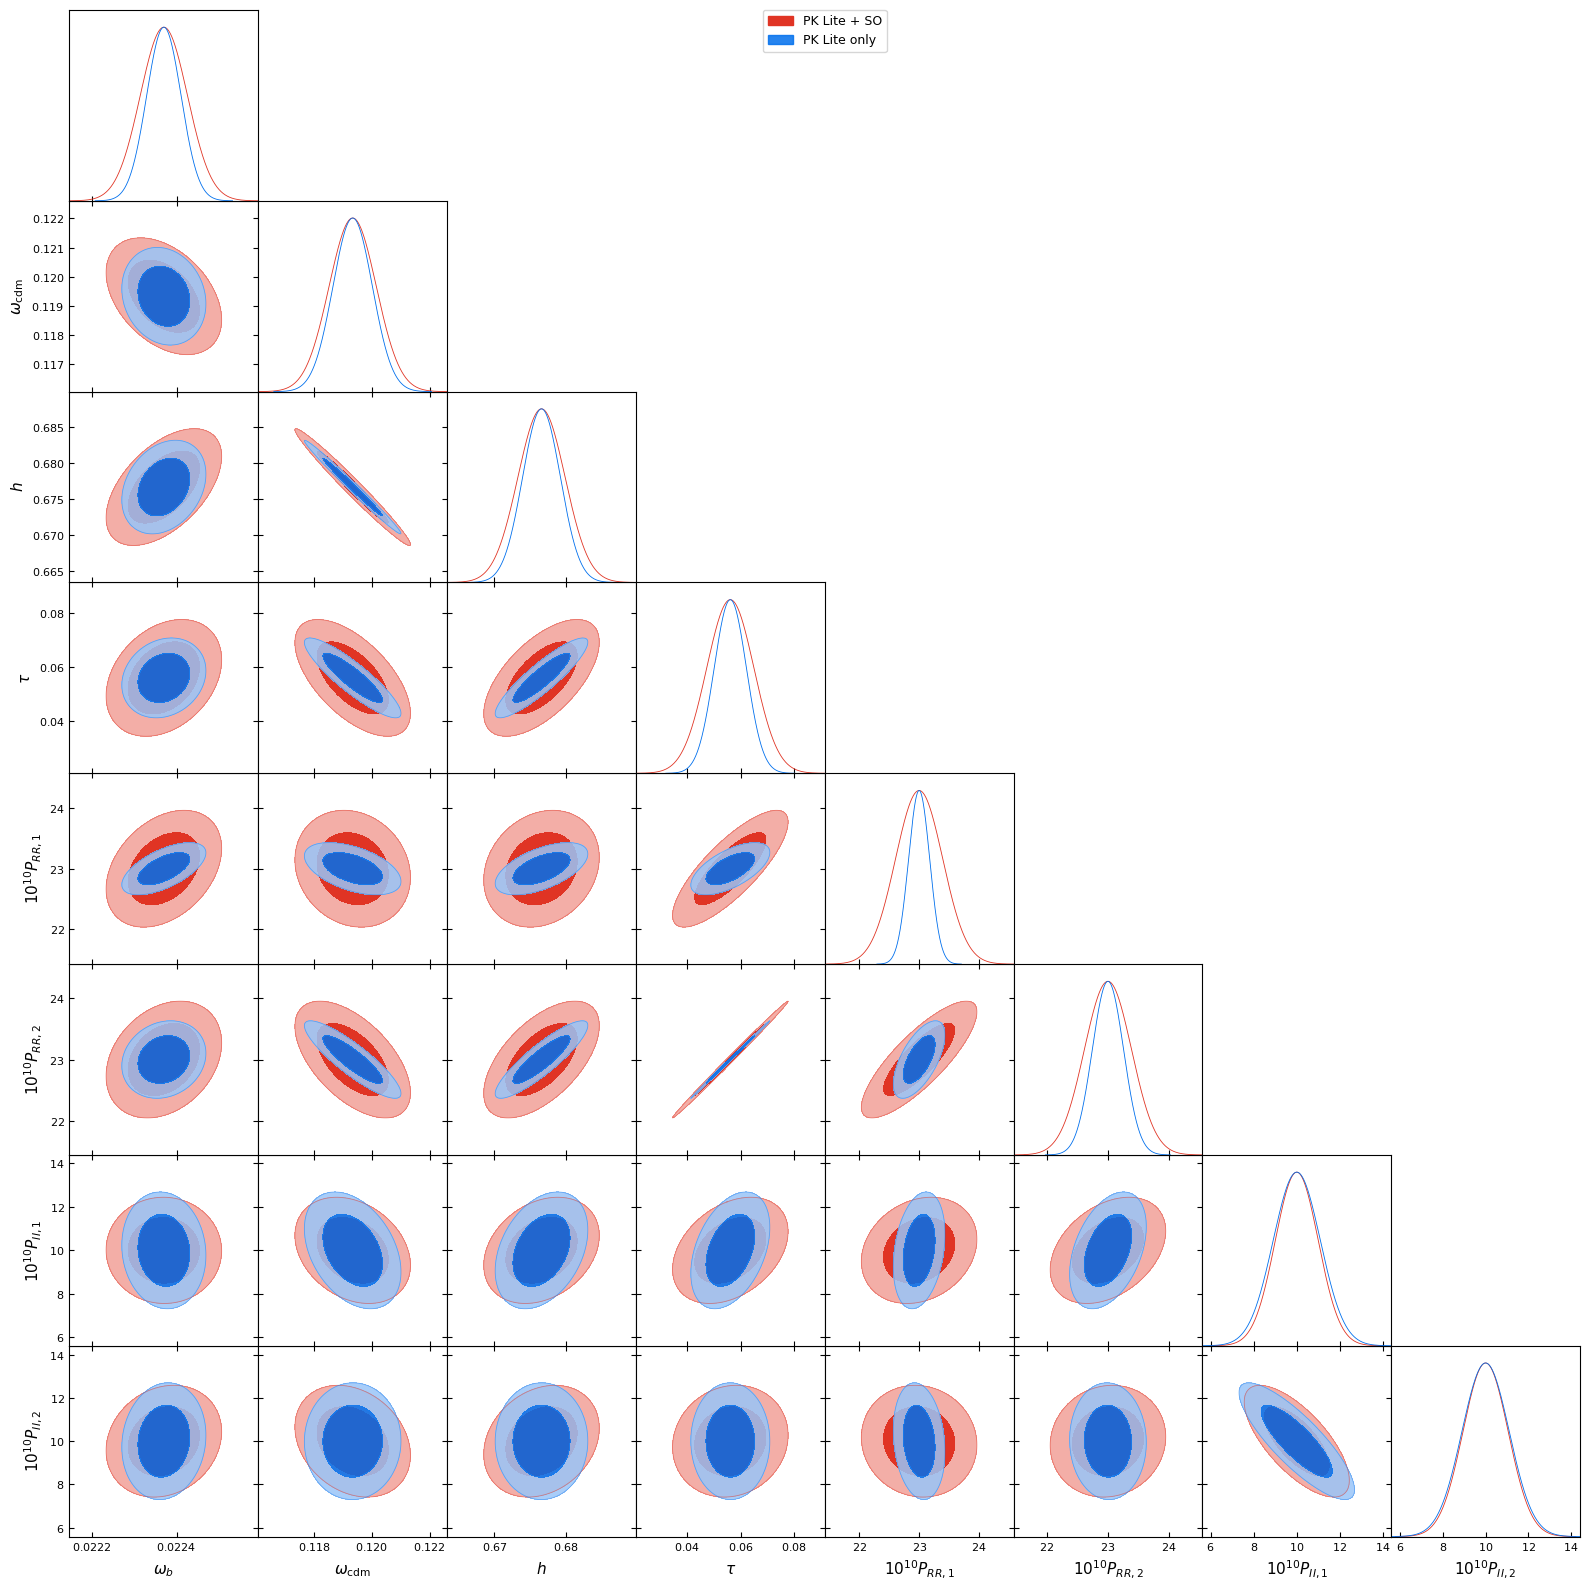

In [160]:
steps_abs = {
    "omega_b":   2.5e-4,
    "omega_cdm": 1.5e-3,
    "h":         6.0e-3,
    "tau_reio":  6.0e-4,
}
steps_scaled10 = {
    "P_RR_1": 0.1,
    "P_RR_2": 0.1,
    "P_II_1": 0.5,
    "P_II_2": 0.5,
}

fisher_5yr = fisher_forecast_ttteee(
    theta0 = theta0,
    param_list = param_list ,
    so_lik_best = so_lik_best,
    compute_cls = compute_cls,
    steps = {**steps_abs, **steps_scaled10},
    scaled_params = SCALED10_PARAMS,
    ell_max = LMAX_FID,
    use_pinv = False,
)

fisher_lite = fisher_forecast_ttteee(
    theta0 = theta0,
    param_list = param_list ,
    so_lik_best = best_lite,
    compute_cls = compute_cls,
    steps = {**steps_abs, **steps_scaled10},
    scaled_params = SCALED10_PARAMS,
    ell_max = LMAX_FID,
    use_pinv = False,
)

plot_save_suite(fisher_5yr,
                'SO + PK Lite Fisher',
               theta0,
               scaled_params = SCALED10_PARAMS,
               save_dir = 'images/040826_fisher')

plot_save_suite(fisher_lite,
                'Planck_Lite',
               theta0,
               scaled_params = SCALED10_PARAMS,
               save_dir = 'images/040826_fisher')

plot_fisher_comparison(
    results       = {'PK Lite + SO': fisher_5yr, 'PK Lite only': fisher_lite},
    theta0        = theta0,
    label_map     = LATEX,
    scaled_params = {'P_RR_1', 'P_RR_2', 'P_II_1', 'P_II_2'},
    save_path     = 'images/040826_fisher/fisher_comparison.png',
)

In [165]:
def check_step_stability(theta0, param, steps_to_test, bands, compute_cls,
                         scaled_params=frozenset(), ell_max=10_000):
    '''
    For a single parameter, compute sigma at multiple step sizes
    and check stability.
    '''
    results = {}
    for step in steps_to_test:
        test_steps = {param: step}
        # single-parameter Fisher for this band
        result = fisher_forecast(
            theta0        = theta0,
            param_list    = [param],
            bands         = bands,
            compute_cls   = compute_cls,
            steps         = test_steps,
            scaled_params = scaled_params,
            ell_max       = ell_max,
        )
        results[step] = result.sigma[0]
        print(f"  step={step:.2e}  ->  sigma={result.sigma[0]:.6f}")
    return results

steps_all = {**steps_abs, **steps_scaled10}
bands = parse_bands_from_best(so_lik_best)

for param, step in steps_all.items():
    print(f"\n--- {param} ---")
    check_step_stability(
        theta0        = theta0,
        param         = param,
        steps_to_test = [step/10, step/2, step, step*2, step*10],
        bands         = bands,
        compute_cls   = compute_cls,
        scaled_params = SCALED10_PARAMS,
    )


--- omega_b ---
  step=2.50e-05  ->  sigma=0.000035
  step=1.25e-04  ->  sigma=0.000036
  step=2.50e-04  ->  sigma=0.000036
  step=5.00e-04  ->  sigma=0.000036
  step=2.50e-03  ->  sigma=0.000036

--- omega_cdm ---
  step=1.50e-04  ->  sigma=0.000132
  step=7.50e-04  ->  sigma=0.000134
  step=1.50e-03  ->  sigma=0.000134
  step=3.00e-03  ->  sigma=0.000134
  step=1.50e-02  ->  sigma=0.000136

--- h ---
  step=6.00e-04  ->  sigma=0.000518
  step=3.00e-03  ->  sigma=0.000519
  step=6.00e-03  ->  sigma=0.000519
  step=1.20e-02  ->  sigma=0.000519
  step=6.00e-02  ->  sigma=0.000534

--- tau_reio ---
  step=6.00e-05  ->  sigma=0.000444
  step=3.00e-04  ->  sigma=0.000439
  step=6.00e-04  ->  sigma=0.000439
  step=1.20e-03  ->  sigma=0.000439
  step=6.00e-03  ->  sigma=0.000439

--- P_RR_1 ---
  step=1.00e-02  ->  sigma=0.136916
  step=5.00e-02  ->  sigma=0.136916
  step=1.00e-01  ->  sigma=0.136915
  step=2.00e-01  ->  sigma=0.136913
  step=1.00e+00  ->  sigma=0.136847

--- P_RR_2 ---
  s

### Testing LCDM

In [292]:
LMAX_FID = 5000

A_s  = 2.1e-9
n_s  = 0.9649
k_piv = 0.05

P_RR_1 = A_s * (0.002 / k_piv)**(n_s - 1)
P_RR_2 = A_s * (0.1   / k_piv)**(n_s - 1)

theta_lcdm = {
    "omega_b": 0.02237,
    "omega_cdm": 0.11933,
    "h": 0.6766,
    "tau_reio": 0.0561,
    "P_RR_1": P_RR_1,
    "P_RR_2": P_RR_2,
}


cmb_theo_lcdm = {}
cmb_theo_lcdm = compute_cls(LMAX_FID, iso_mode = None, **theta_lcdm)

In [293]:
'''
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

ell_lite = so_lik_unif['data']['PK_lite']['ell']
pref_lite = _make_pref(ell_lite)
cl_lite   = pref_lite * so_lik_unif['data']['PK_lite']['c_ell']
ax1.plot(ell_lite, cl_lite, label='TT, PK_Lite', color='black')

ell_cls  = cmb_theo_lcdm['ell']
pref_cls = _make_pref(ell_cls)
cl_cls   = pref_cls * cmb_theo_lcdm['TT']
ax1.plot(ell_cls[:2500], cl_cls[:2500], label='TT, Classy', color='orange')

ax1.legend()
ax1.set_ylabel(r'$D_\ell$')
ax1.set_title('Lite vs Classy Comparison, LCDM')

cl_cls_interp = _interp_to(ell_lite, ell_cls, cl_cls)
ratio = cl_cls_interp / cl_lite

ax2.plot(ell_lite[:2500], ratio[:2500], color='orange')
ax2.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax2.set_ylabel('Classy / Lite')
ax2.set_xlabel(r'$\ell$')
ax2.set_ylim(0.9, 1.1)

plt.tight_layout()
plt.savefig('classy_confirmation.png')
plt.show()
'''

<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_469547/115985154.py:17: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_ylabel(r'$D_\ell$')


"\nfig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7),\n                                gridspec_kw={'height_ratios': [3, 1]},\n                                sharex=True)\n\nell_lite = so_lik_unif['data']['PK_lite']['ell']\npref_lite = _make_pref(ell_lite)\ncl_lite   = pref_lite * so_lik_unif['data']['PK_lite']['c_ell']\nax1.plot(ell_lite, cl_lite, label='TT, PK_Lite', color='black')\n\nell_cls  = cmb_theo_lcdm['ell']\npref_cls = _make_pref(ell_cls)\ncl_cls   = pref_cls * cmb_theo_lcdm['TT']\nax1.plot(ell_cls[:2500], cl_cls[:2500], label='TT, Classy', color='orange')\n\nax1.legend()\nax1.set_ylabel(r'$D_\\ell$')\nax1.set_title('Lite vs Classy Comparison, LCDM')\n\ncl_cls_interp = _interp_to(ell_lite, ell_cls, cl_cls)\nratio = cl_cls_interp / cl_lite\n\nax2.plot(ell_lite[:2500], ratio[:2500], color='orange')\nax2.axhline(1.0, color='black', linestyle='--', linewidth=1)\nax2.set_ylabel('Classy / Lite')\nax2.set_xlabel(r'$\\ell$')\nax2.set_ylim(0.9, 1.1)\n\nplt.tight_layout()\nplt.save

In [294]:
out_lcdm = {
    'metadata': {},
    'data':{},
}
out_lcdm =  add_lite_to_out(out_lcdm,lite_data)

In [295]:
best_lcdm = make_best_per_bin(out_lcdm, ell_scheme)
cov_lcdm = make_ttteee_cov(best_lcdm)

In [296]:
def parse_spectrum_bands_planck_lite(
    planck_data: dict,
    cell_types:  list[str] = None,
) -> list[SpectrumBand]:
    if cell_types is None:
        cell_types = list(planck_data.keys())

    bands = []
    for cell_type in cell_types:
        d     = planck_data[cell_type]
        ell   = np.asarray(d["ell"],   dtype=float)
        dell  = np.asarray(d["dell"], dtype=float)

        cov = np.asarray(d["cov"], dtype=float)

        bands.append(SpectrumBand(
            exp_key   = "PlanckLite",
            channel   = f"PlanckLite_{cell_type}",
            cell_type = cell_type,
            ell       = ell.astype(int),
            dell      = dell,
            fsky      = 0.6,
            cov       = cov,
        ))

    return bands

bands_lite = parse_spectrum_bands_planck_lite(
    planck_data = lite_data,
    cell_types  = ['TT', 'TE', 'EE'],
)

In [297]:
param_list_lcdm = [
    "omega_b", "omega_cdm", "h", "tau_reio",
    "P_RR_1", "P_RR_2"
]

steps_abs_lcdm = {
    "omega_b": 2.5e-5,
    "omega_cdm": 1.5e-4,
    "h": 6.0e-4,
    "tau_reio": 6.0e-5,
}

SCALED10_PARAMS_lcdm = {"P_RR_1", "P_RR_2"}

steps_scaled10_lcdm = {
    "P_RR_1": 0.01,
    "P_RR_2": 0.01,
}


fisher_lcdm = fisher_forecast_ttteee(
    theta0 = theta_lcdm,
    param_list = param_list_lcdm ,
    so_lik_best = best_lcdm,
    compute_cls = compute_cls,
    steps = {**steps_abs, **steps_scaled10_lcdm},
    scaled_params = SCALED10_PARAMS_lcdm,
    ell_max = LMAX_FID,
    use_pinv = False,
)

,Fiducial,sigma,S/N
omega_b,0.02237,0.000141,158.649310
omega_cdm,0.11933,0.001326,89.962588
h,0.67660,0.005986,113.023158
tau_reio,0.05610,0.030652,1.830231
P_RR_1,23.00000,1.355490,16.968033
P_RR_2,23.00000,1.234585,18.629741


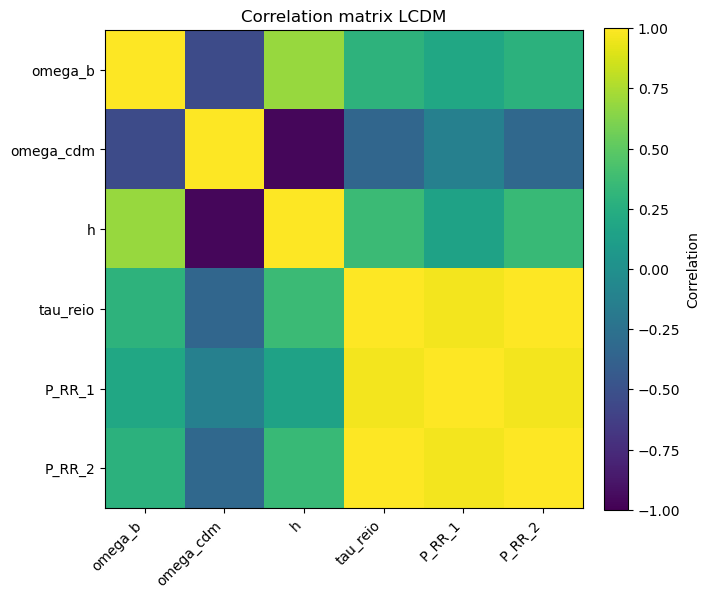

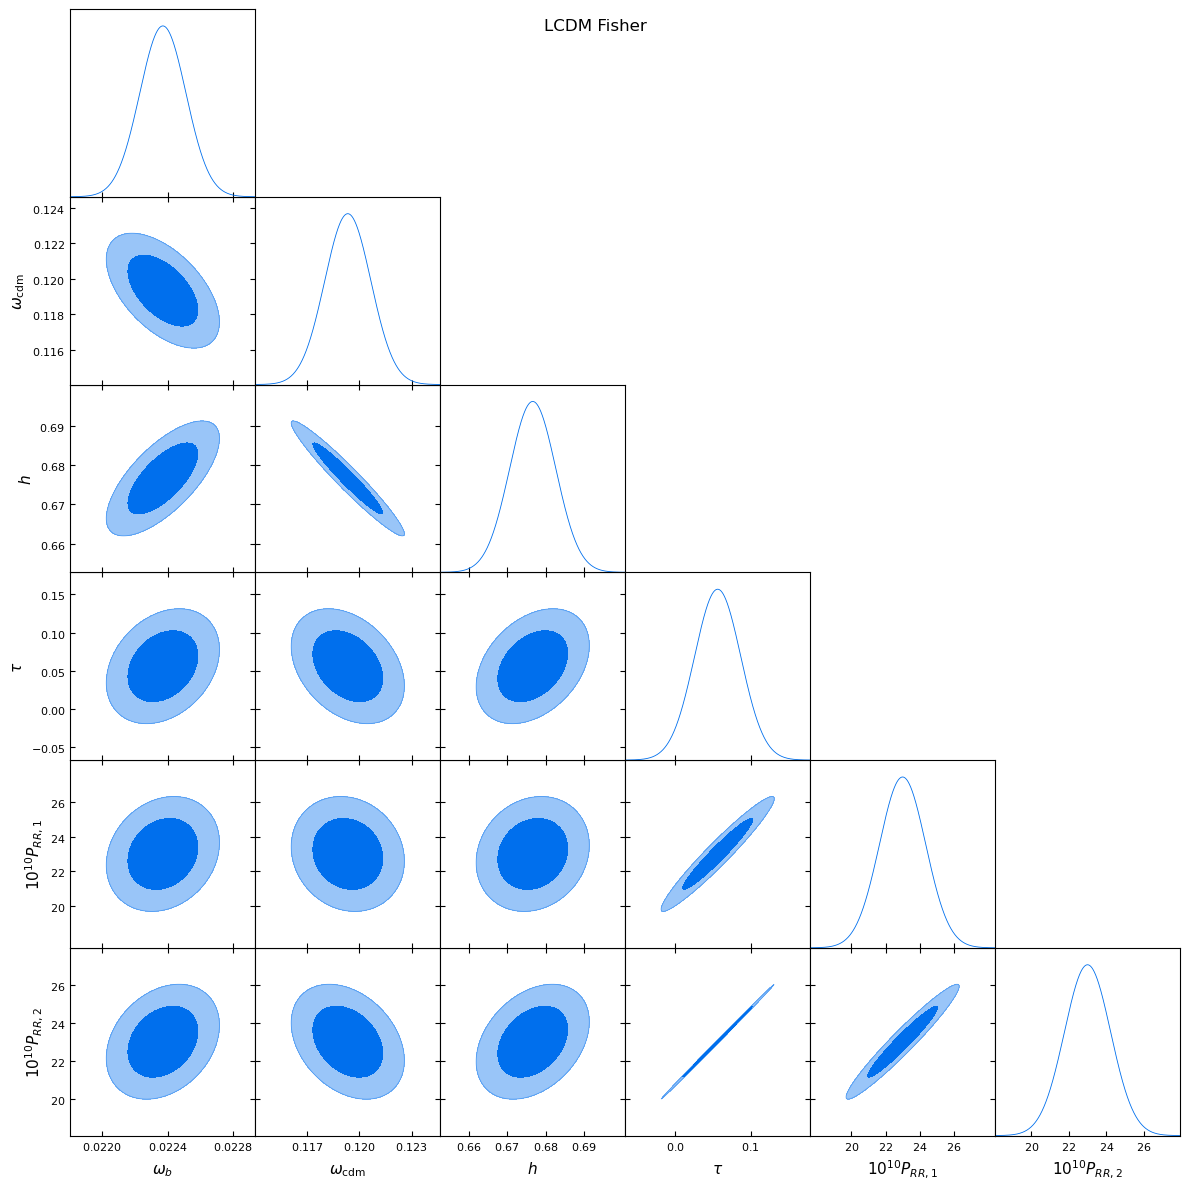

In [298]:
plot_save_suite(fisher_lcdm,
                'LCDM',
               theta_lcdm,
               scaled_params = SCALED10_PARAMS_lcdm,
                LATEX = {
                            "omega_b":   r"\omega_b",
                            "omega_cdm": r"\omega_{\rm cdm}",
                            "h":         r"h",
                            "tau_reio":  r"\tau",
                            "P_RR_1":    r"10^{10}P_{RR,1}",
                            "P_RR_2":    r"10^{10}P_{RR,2}",
                        },
               save_dir = 'images/040826_fisher')

### LCDM -- NEW FORMULA (fml)